# GLOBE Data Curation: Model Diagnostics

This notebook validates the mathematical health and robustness of the automated curation framework. It evaluates the convergence of the Bayesian Hierarchical Models (BHMs) using Markov Chain Monte Carlo (MCMC) diagnostics (such as Gelman-Rubin statistics, trace plots, and divergence analysis). Furthermore, it contrasts empirical hardware limits against Posterior Predictive Checks (PPCs) to ensure the framework accurately captures natural water transparency trends without overfitting to the physical constraints of citizen science instruments.

### Diagnostics Overview

1. **MCMC Convergence Diagnostics:** Assessing the health, mixing, and geometry of the Bayesian sampling (Trace Plots, Divergence Analysis, Hierarchical Shrinkage, and Statistical Summaries).
2. **Empirical Instrument Limits:** Isolating right-censored transparency tube records to explicitly visualize the physical constraints of standard-issue GLOBE hardware.
3. **Posterior Predictive Checks (PPC):** Overlaying simulated posterior data onto actual observations to validate the structural fit and predictive robustness of the model.
4. **Quantitative Model Scoring (WAIC & LOO):** Computing information criteria to estimate the out-of-sample predictive accuracy of both Bayesian Hierarchical Models.

In [11]:
# =============================================================================
# ENVIRONMENT SETUP
# =============================================================================
%matplotlib inline
import os
import sqlite3
import sys
import textwrap
import warnings

import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from IPython.display import Markdown, display
from scipy.stats import truncnorm

# Suppress harmless small-variance mathematical warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="For one or more samples the posterior variance of the log predictive densities")
warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto distribution is greater than 0.70")

# Shift the notebook's working directory up to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Ensure output directory exists for saving diagnostic plots
output_dir = 'output/figures/02_model_diagnostics'
os.makedirs(output_dir, exist_ok=True)

## 1. MCMC Convergence Diagnostics
Before interpreting the output of a Bayesian model, it is critical to ensure the MCMC chains converged successfully. We evaluate the Gelman-Rubin statistic ($\hat{R}$) and the trace plots.
* An $\hat{R}$ value $\approx 1.0$ (strictly $< 1.01$) indicates convergence.
* **Trace Plots:** The different colors represent the 4 independent Markov chains. Healthy convergence is indicated when all chains overlap smoothly rather than forming flat, distinct lines.

Loading Secchi Disk trace...

SECCHI DISK CONVERGENCE SUMMARY


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
global_mu,0.634,0.205,0.247,1.028,0.002,0.002,7324.0,9505.0,1.0
global_sigma,0.539,0.219,0.169,0.977,0.003,0.002,3444.0,3095.0,1.0
water_source_sigma[estuary],0.865,0.495,0.000,1.702,0.006,0.003,5417.0,5293.0,1.0
water_source_sigma[river],1.154,0.242,0.721,1.602,0.003,0.002,4940.0,7863.0,1.0
water_source_sigma[stream],1.456,0.398,0.755,2.191,0.004,0.003,8703.0,10310.0,1.0
water_source_sigma[bay],0.550,0.223,0.230,0.968,0.003,0.003,6010.0,10138.0,1.0
water_source_sigma[unknown],1.559,0.094,1.379,1.733,0.002,0.001,3747.0,7270.0,1.0
water_source_sigma[lake],0.832,0.290,0.328,1.373,0.004,0.002,5403.0,6929.0,1.0
water_source_sigma[other],0.995,0.287,0.486,1.528,0.003,0.002,6559.0,9015.0,1.0
water_source_sigma[ocean],1.347,0.482,0.520,2.317,0.005,0.004,8869.0,7055.0,1.0



Rendering Secchi Disk trace plots...

✅ Secchi disk MCMC trace plot saved successfully to: output/figures/02_model_diagnostics/diag_trace_disk.png


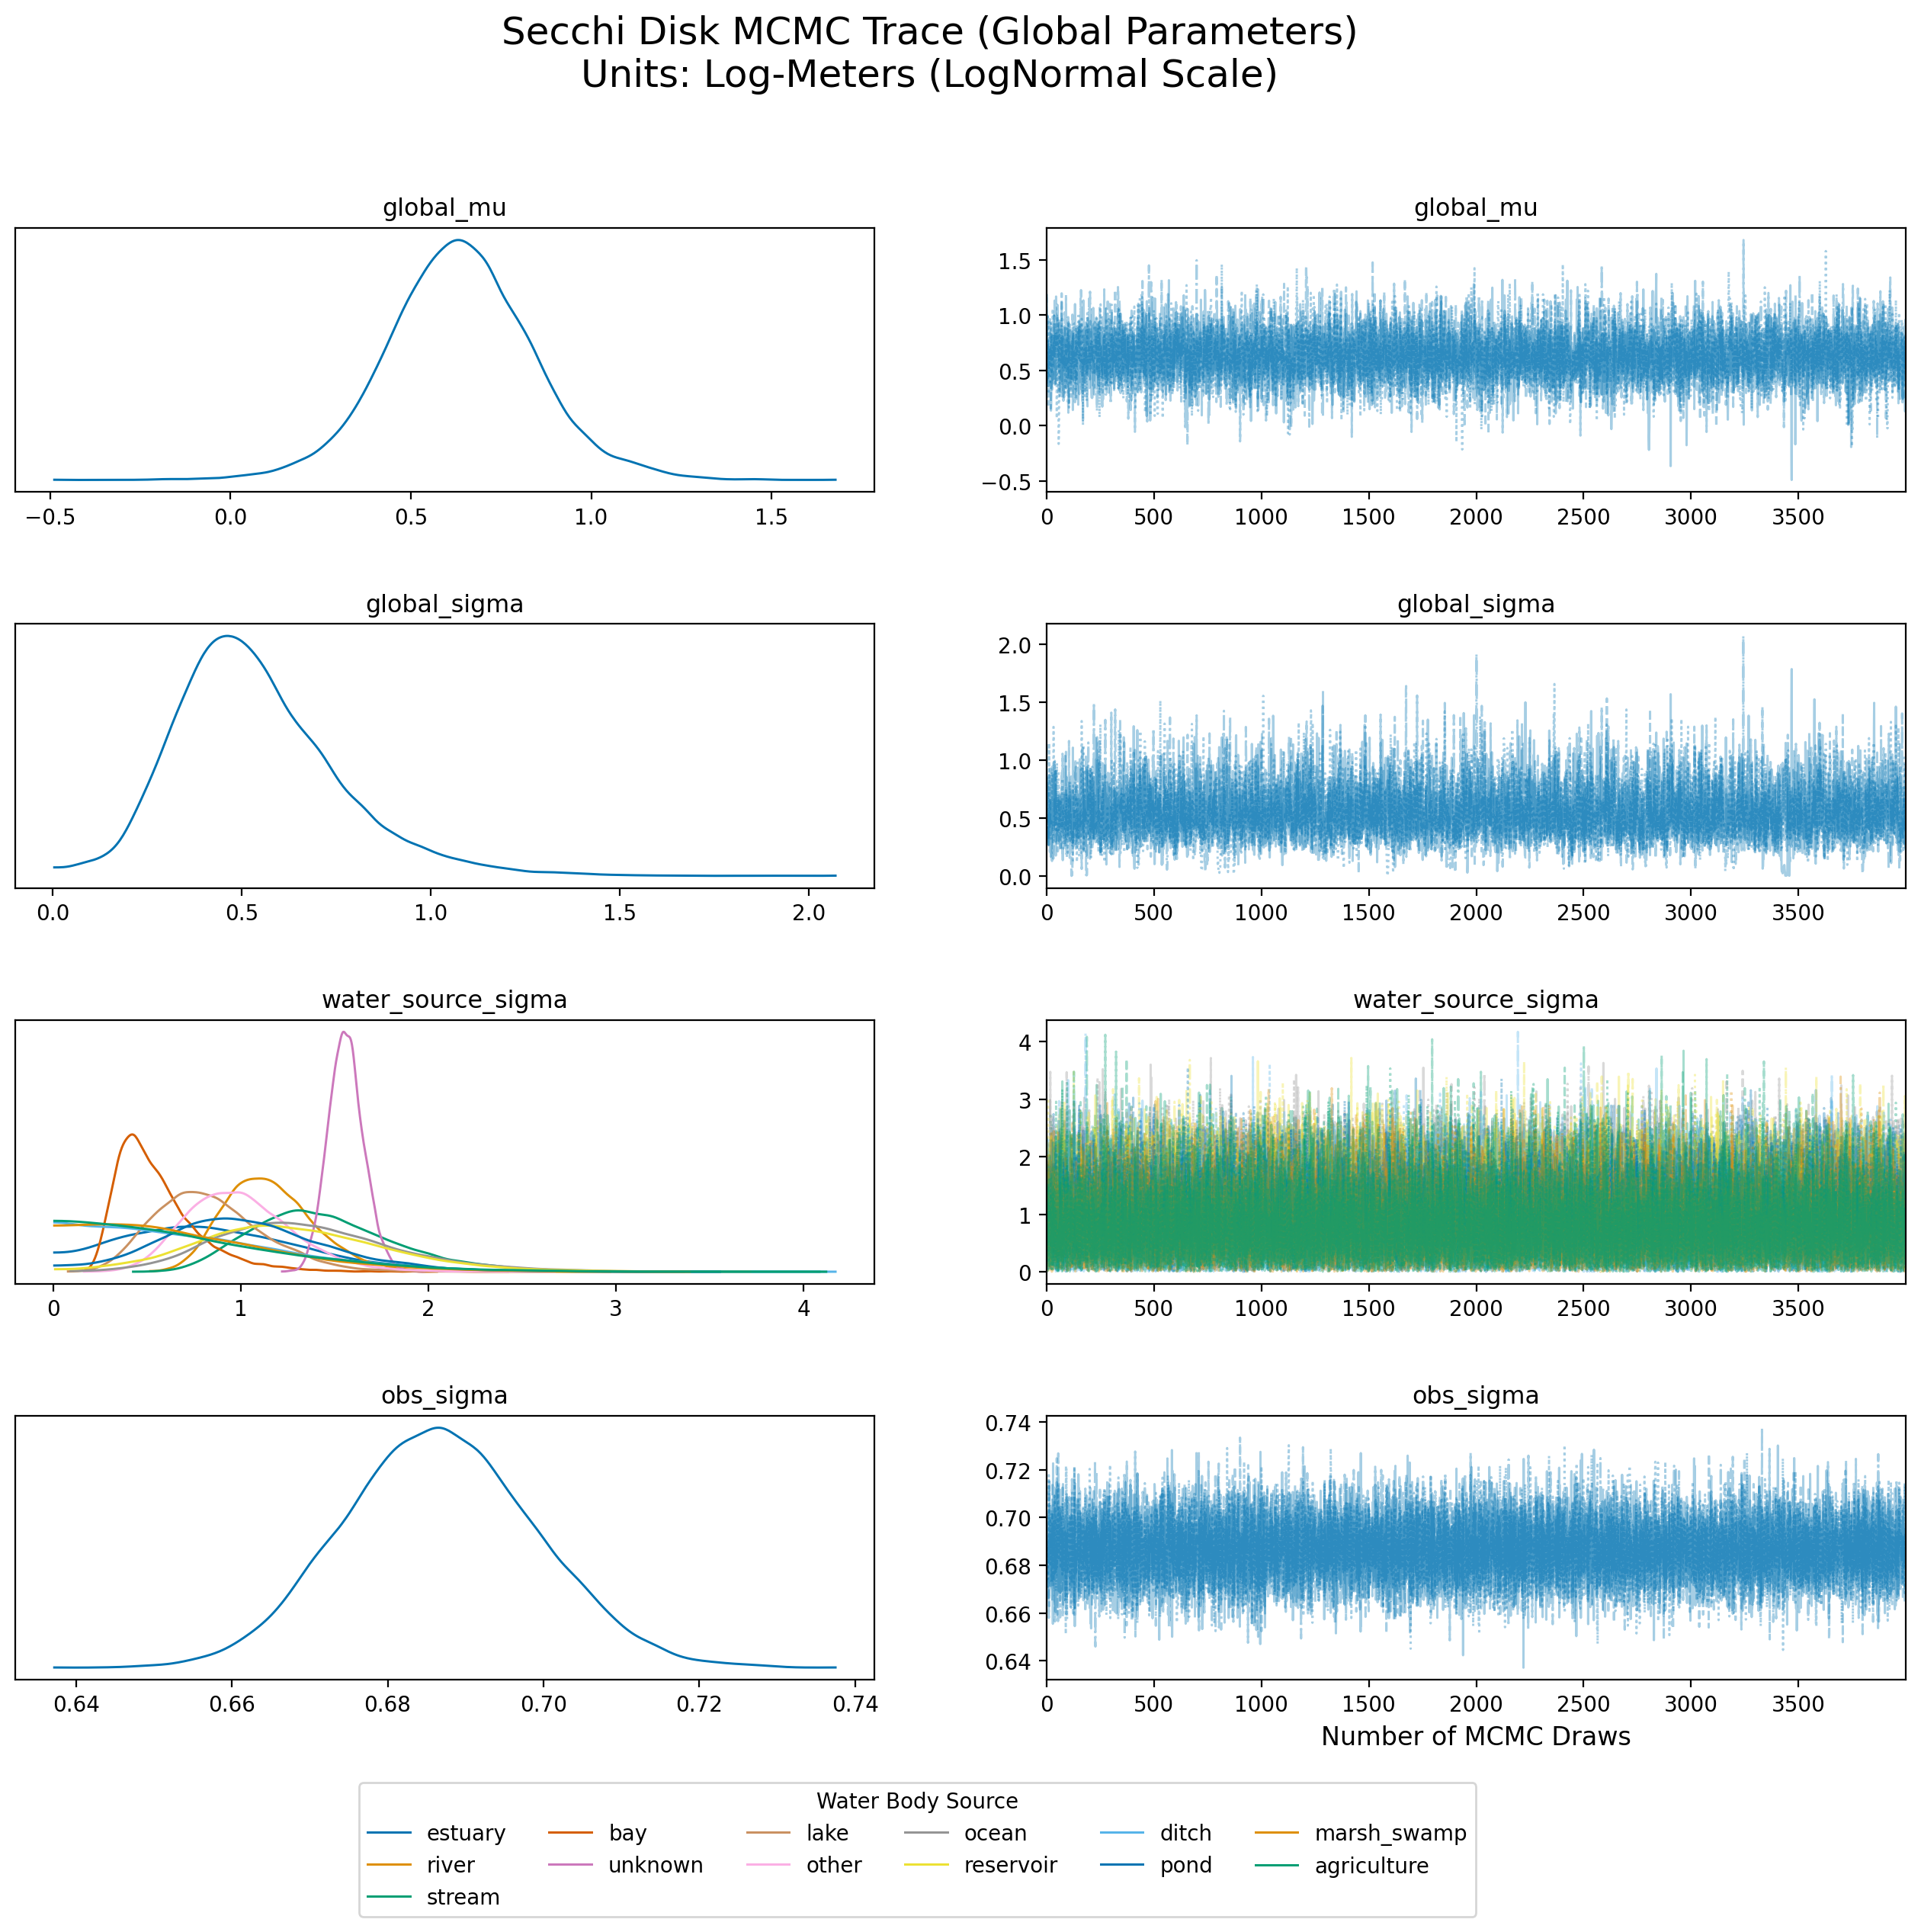


Loading Transparency Tube trace...

TRANSPARENCY TUBE CONVERGENCE SUMMARY


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
global_mu,142.251,15.960,112.023,171.434,0.223,0.129,5113.0,8452.0,1.0
global_sigma,52.078,9.643,34.918,70.529,0.106,0.071,7942.0,9700.0,1.0
water_source_sigma[lake],52.264,5.736,41.742,63.110,0.044,0.041,16882.0,12412.0,1.0
water_source_sigma[other],97.425,6.114,86.104,108.999,0.040,0.048,23227.0,13092.0,1.0
water_source_sigma[unknown],116.737,4.850,107.591,125.722,0.047,0.033,10595.0,12245.0,1.0
water_source_sigma[stream],57.019,5.150,47.346,66.836,0.047,0.035,11951.0,12818.0,1.0
water_source_sigma[river],97.715,5.611,87.471,108.449,0.049,0.037,13308.0,13166.0,1.0
water_source_sigma[bay],15.923,9.503,0.012,31.714,0.112,0.057,6416.0,6257.0,1.0
water_source_sigma[pond],60.550,5.682,49.966,71.193,0.042,0.041,17948.0,12418.0,1.0
water_source_sigma[ditch],9.845,7.129,0.004,22.472,0.059,0.050,11067.0,7534.0,1.0



Rendering Transparency Tube trace plots...

✅ Transparency tube MCMC trace plot saved successfully to: output/figures/02_model_diagnostics/diag_trace_tube.png


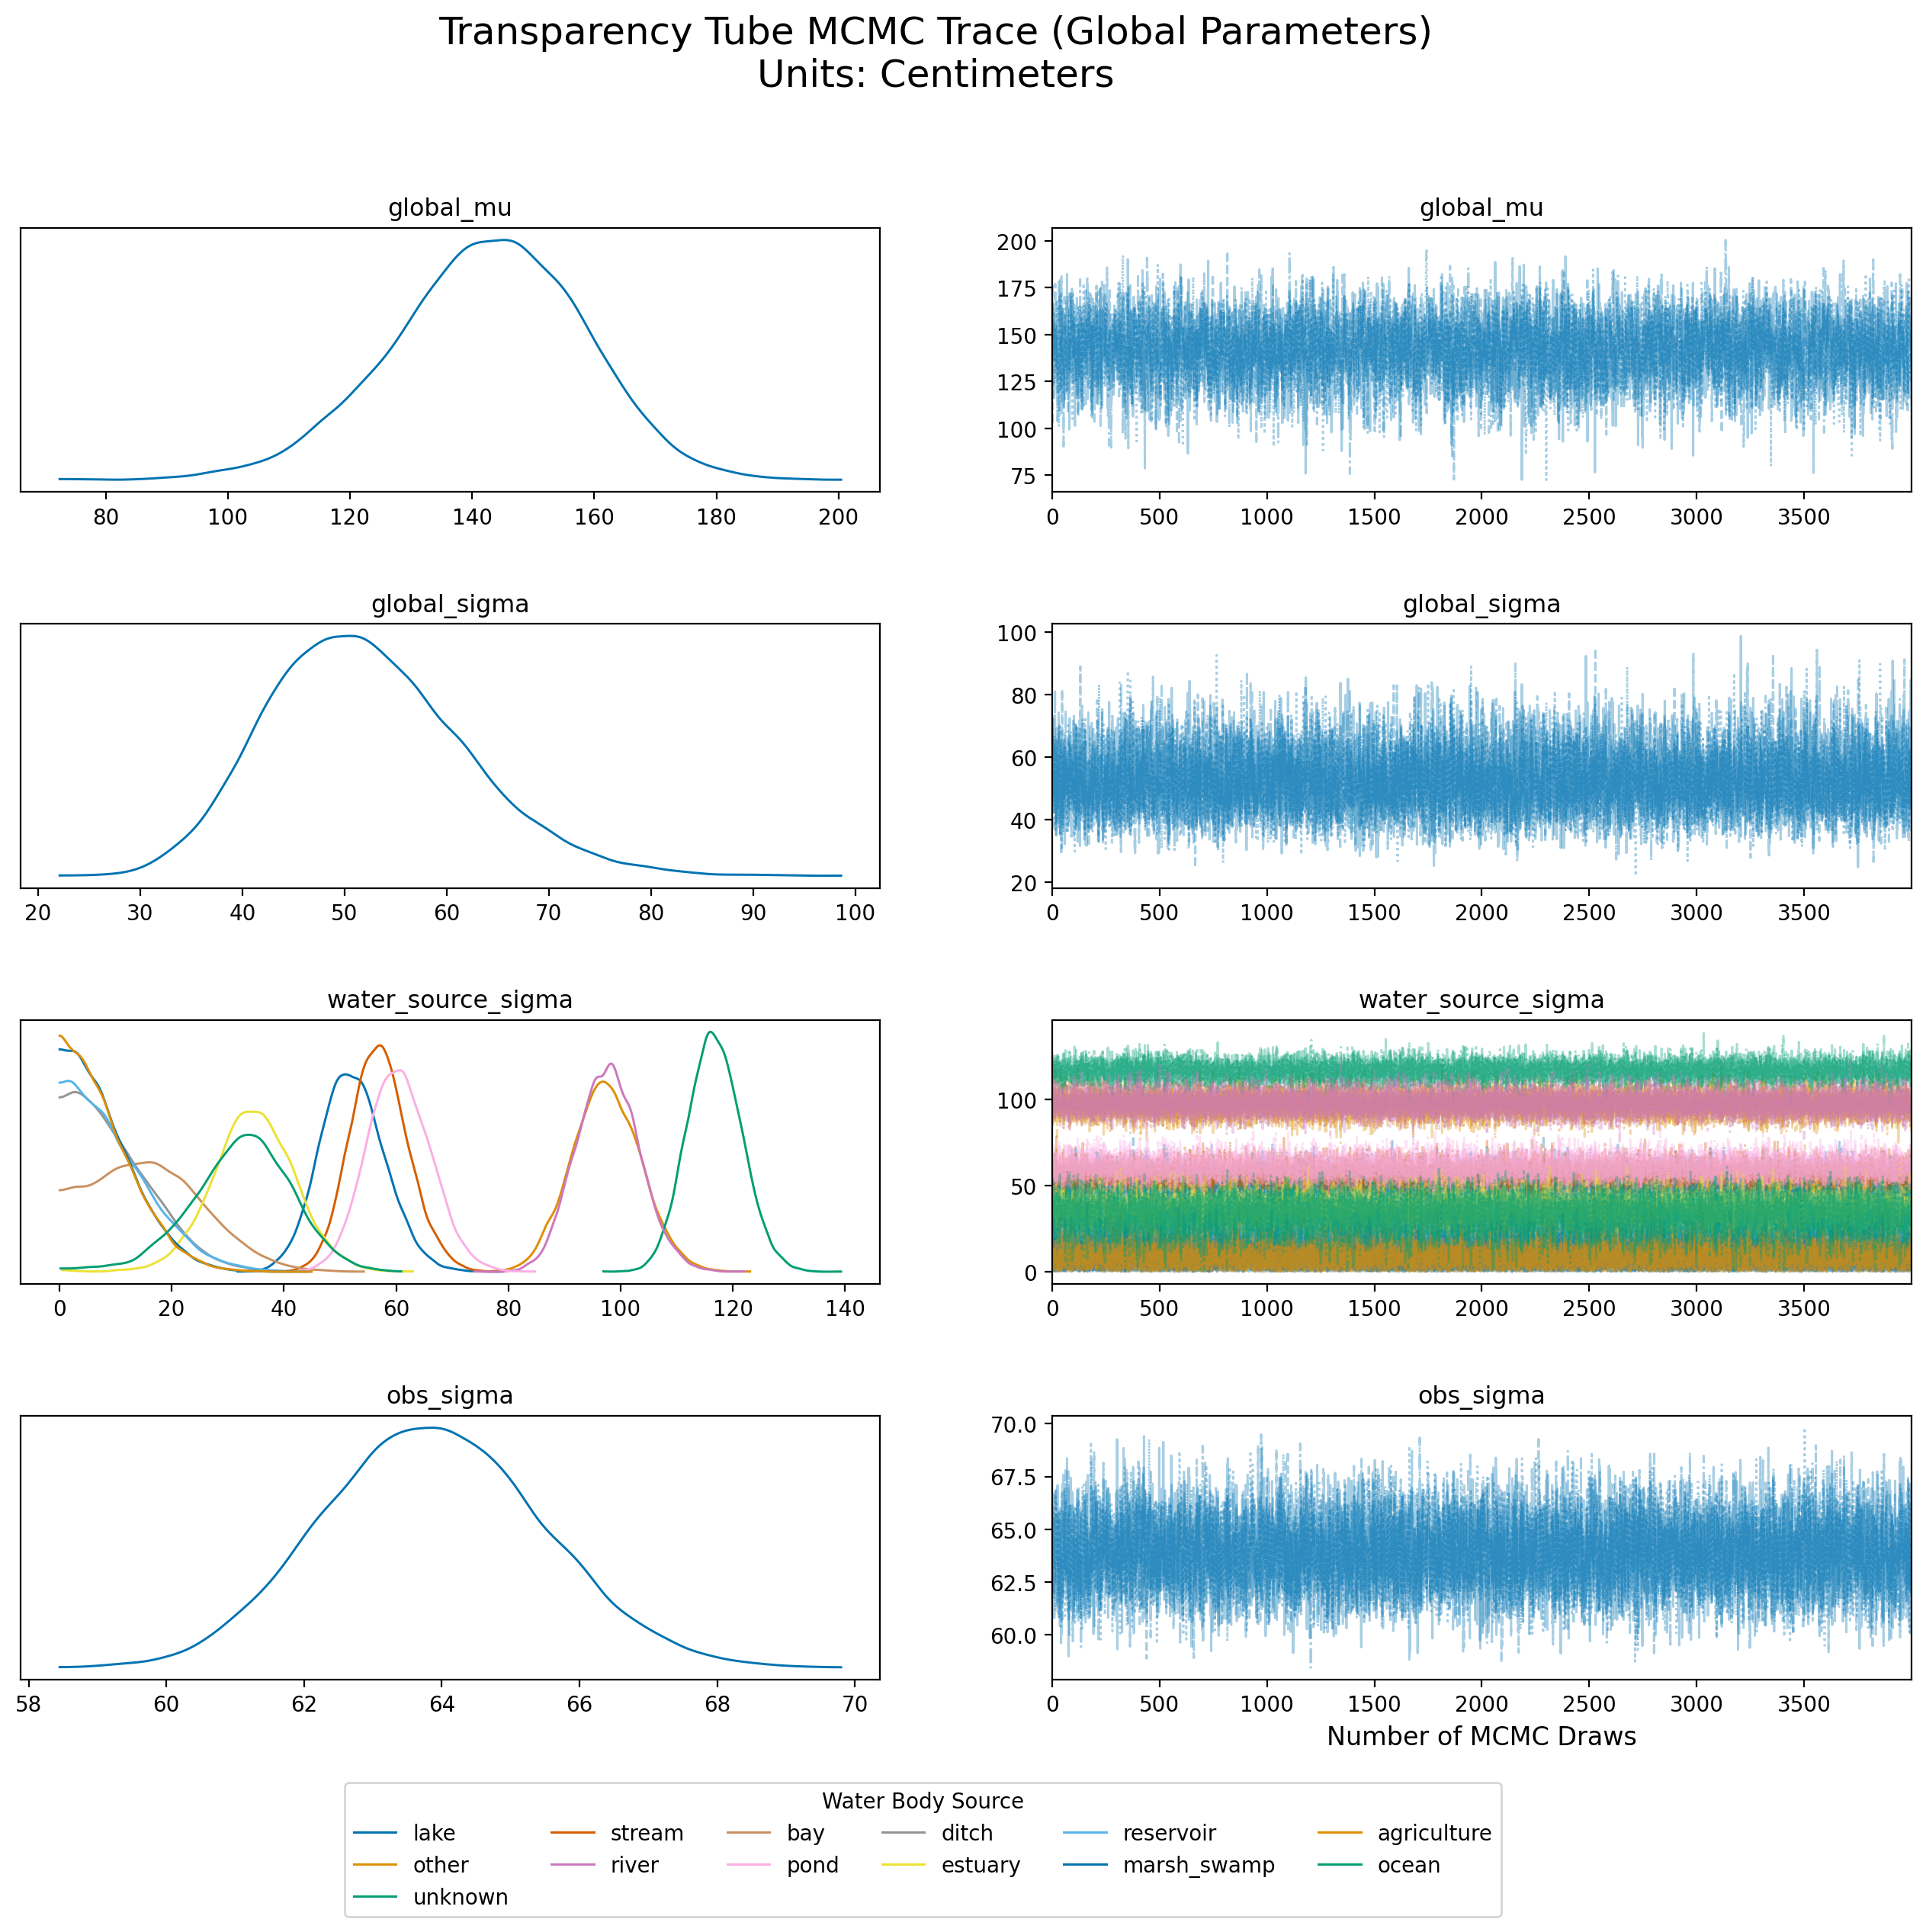


### Interpretation of MCMC Trace Plots

The plots above visualize the sampling history and the resulting probability distributions for the core global parameters of our Bayesian Hierarchical Model. Evaluating these traces is the first step in confirming the mathematical health of the curation framework.

**How to Read the Plots:**
* **Left Column (Posterior Distributions):** These density curves (KDEs) represent the model's final combined belief about the true value of each parameter. Because we combined the sampling chains, you will see a single smooth, bell-shaped curve for global scalar parameters. For our grouped parameter (`water_source_sigma`), the multiple overlapping colors represent the different water source categories, not the individual Markov chains.
* **Right Column (Sampling Trace):** This shows the sequential path the sampler took across the iterations. Healthy convergence is indicated when the trace densely and rapidly oscillates around a stable central value, often described as looking like a "fuzzy caterpillar." If the trace wanders wildly, flatlines, or shows long-term directional trends, the model has failed to converge.

**Understanding the Model Parameters:**
To interpret these global estimates, we map the mathematical parameters directly back to the physical reality of the GLOBE data collection process:

| Parameter | Statistical Role | Physical Interpretation |
| :--- | :--- | :--- |
| **`global_mu`** | Grand Mean | The baseline average water transparency across all sites and water types worldwide. |
| **`global_sigma`** | Global Variance | The expected natural variation in transparency between completely different types of water bodies (e.g., a typical lake vs. a typical swamp). |
| **`water_source_sigma`** | Group Variance | The variation among individual sites that share the same water type (e.g., how much one specific lake differs from another lake). |
| **`obs_sigma`** | Pooled Observation Error | The baseline "noise" of a measurement. This captures human error, instrument limitations, and day-to-day weather fluctuations. |
| **`site_mu`** | Local Mean | The true, underlying transparency signature of a single, specific GPS location. *(Note: Not plotted above due to the high volume of sites, but this is the primary parameter used to flag statistical outliers).* |


In [12]:
# =============================================================================
# TRACE INGESTION & SUMMARY
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Clear xarray's file handle cache to ensure clean trace loads
xr.backends.file_manager.FILE_CACHE.clear()

# Paths to the saved NetCDF trace files for each model
DISK_TRACE_PATH = 'output/traces/disk_trace.nc'
TUBE_TRACE_PATH = 'output/traces/tube_trace.nc'

# Variables to inspect: global hyperpriors and group/observation-level sigmas
target_vars = ["global_mu", "global_sigma", "water_source_sigma", "obs_sigma"]

try:
    # --- 1. SECCHI DISK DIAGNOSTICS ---
    print("Loading Secchi Disk trace...")
    disk_trace = az.from_netcdf(DISK_TRACE_PATH)

    print("\n" + "="*50)
    print("SECCHI DISK CONVERGENCE SUMMARY")
    print("="*50)
    display(az.summary(disk_trace, var_names=target_vars))

    print("\nRendering Secchi Disk trace plots...\n")
    axes_disk = az.plot_trace(
        disk_trace,
        var_names=target_vars,
        compact=True,
        combined=True,
        legend=False,
        figsize=(16, 14),
        divergences=False
    )

    # Extract actual water source category names directly from the trace metadata
    water_categories_disk = disk_trace.posterior.coords["water_source"].values

    # Extract legend handles from the water_source_sigma subplot for custom legend
    handles_disk = axes_disk[2, 0].get_lines()[:len(water_categories_disk)]

    # Attach the custom legend to the bottom-left subplot
    axes_disk[-1, 0].legend(
        handles_disk,
        water_categories_disk,
        title="Water Body Source",
        loc='upper center',
        bbox_to_anchor=(1.05, -0.35),
        ncol=6,
        fontsize=10
    )

    # Add x-axis label to the iteration/sample count plot
    axes_disk[-1, 1].set_xlabel("Number of MCMC Draws", fontsize=12)

    plt.suptitle(
        "Secchi Disk MCMC Trace (Global Parameters)\n"
        "Units: Log-Meters (LogNormal Scale)",
        fontsize=18,
        y=0.98
    )
    plt.subplots_adjust(hspace=0.5, bottom=0.20)
    if save_plot:
        disk_trace_fig_path = os.path.join(output_dir, 'diag_trace_disk.png')
        plt.savefig(disk_trace_fig_path, bbox_inches='tight', dpi=300)
        print(f"✅ Secchi disk MCMC trace plot saved successfully to: {disk_trace_fig_path}")
    plt.show()

    # --- 2. TRANSPARENCY TUBE DIAGNOSTICS ---
    print("\nLoading Transparency Tube trace...")
    tube_trace = az.from_netcdf(TUBE_TRACE_PATH)

    print("\n" + "="*50)
    print("TRANSPARENCY TUBE CONVERGENCE SUMMARY")
    print("="*50)
    display(az.summary(tube_trace, var_names=target_vars))

    print("\nRendering Transparency Tube trace plots...\n")
    axes_tube = az.plot_trace(
        tube_trace,
        var_names=target_vars,
        compact=True,
        combined=True,
        legend=False,
        figsize=(16, 14),
        divergences=False
    )

    water_categories_tube = tube_trace.posterior.coords["water_source"].values

    # Extract legend handles from the water_source_sigma subplot for custom legend
    handles_tube = axes_tube[2, 0].get_lines()[:len(water_categories_tube)]

    # Attach the custom legend to the bottom-left subplot
    axes_tube[-1, 0].legend(
        handles_tube,
        water_categories_tube,
        title="Water Body Source",
        loc='upper center',
        bbox_to_anchor=(1.05, -0.35),
        ncol=6,
        fontsize=10
    )

    # Add x-axis label to the iteration/sample count plot
    axes_tube[-1, 1].set_xlabel("Number of MCMC Draws", fontsize=12)

    plt.suptitle(
        "Transparency Tube MCMC Trace (Global Parameters)\n"
        "Units: Centimeters",
        fontsize=18,
        y=0.98
    )
    plt.subplots_adjust(hspace=0.5, bottom=0.20)
    if save_plot:
        tube_trace_fig_path = os.path.join(output_dir, 'diag_trace_tube.png')
        plt.savefig(tube_trace_fig_path, bbox_inches='tight', dpi=300)
        print(f"✅ Transparency tube MCMC trace plot saved successfully to: {tube_trace_fig_path}")
        
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}")
    print(f"Ensure you exported the traces and that they exist in {os.path.dirname(DISK_TRACE_PATH)}/")


# --- Embedded Interpretation ---
caption_trace = """
### Interpretation of MCMC Trace Plots

The plots above visualize the sampling history and the resulting probability distributions for the core global parameters of our Bayesian Hierarchical Model. Evaluating these traces is the first step in confirming the mathematical health of the curation framework.

**How to Read the Plots:**
* **Left Column (Posterior Distributions):** These density curves (KDEs) represent the model's final combined belief about the true value of each parameter. Because we combined the sampling chains, you will see a single smooth, bell-shaped curve for global scalar parameters. For our grouped parameter (`water_source_sigma`), the multiple overlapping colors represent the different water source categories, not the individual Markov chains.
* **Right Column (Sampling Trace):** This shows the sequential path the sampler took across the iterations. Healthy convergence is indicated when the trace densely and rapidly oscillates around a stable central value, often described as looking like a "fuzzy caterpillar." If the trace wanders wildly, flatlines, or shows long-term directional trends, the model has failed to converge.

**Understanding the Model Parameters:**
To interpret these global estimates, we map the mathematical parameters directly back to the physical reality of the GLOBE data collection process:

| Parameter | Statistical Role | Physical Interpretation |
| :--- | :--- | :--- |
| **`global_mu`** | Grand Mean | The baseline average water transparency across all sites and water types worldwide. |
| **`global_sigma`** | Global Variance | The expected natural variation in transparency between completely different types of water bodies (e.g., a typical lake vs. a typical swamp). |
| **`water_source_sigma`** | Group Variance | The variation among individual sites that share the same water type (e.g., how much one specific lake differs from another lake). |
| **`obs_sigma`** | Pooled Observation Error | The baseline "noise" of a measurement. This captures human error, instrument limitations, and day-to-day weather fluctuations. |
| **`site_mu`** | Local Mean | The true, underlying transparency signature of a single, specific GPS location. *(Note: Not plotted above due to the high volume of sites, but this is the primary parameter used to flag statistical outliers).* |
"""
display(Markdown(caption_trace))


Checking location of divergences in the parameter space...

✅ Divergence plot saved successfully to: output/figures/02_model_diagnostics/diag_divergence_check.png


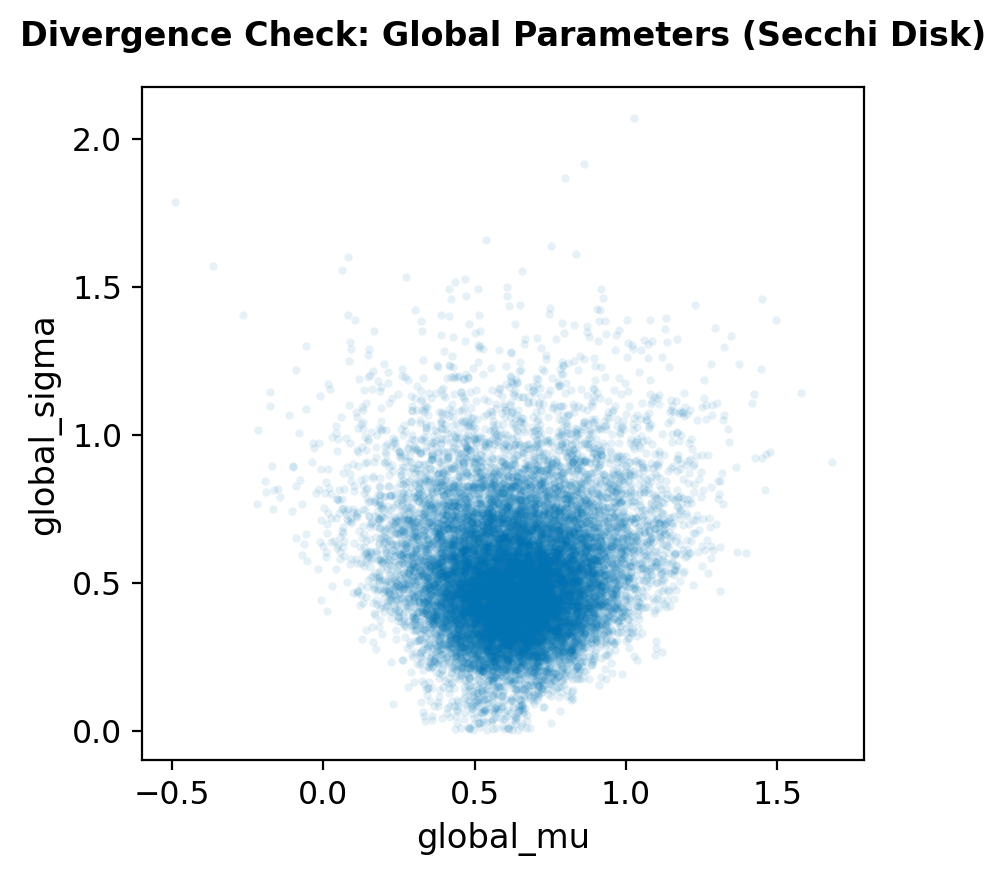


### Interpretation of Divergence Analysis

During Markov Chain Monte Carlo (MCMC) sampling (specifically using the NUTS sampler), a **divergence** occurs when the algorithm encounters a region of extreme curvature in the probability distribution, causing its numerical approximation to briefly fail.

**Key Takeaways:**
* **Perfect Exploration:** Our Secchi Disk model reported **0 divergences** out of 16,000 total draws. The probability space was navigated flawlessly without any numerical approximation failures.
* **Mathematical Health:** This indicates an incredibly healthy model geometry. The sampler did not encounter any extreme curvature (such as 'Neal's Funnel') that it couldn't handle, ensuring our global mean (`global_mu`) estimates are unbiased.


In [13]:
# =============================================================================
# DIVERGENCE ANALYSIS (GEOMETRY CHECK)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
print("Checking location of divergences in the parameter space...\n")

# Build the base pair plot manually, bypassing ArviZ's built-in divergence markers
ax = az.plot_pair(
    disk_trace,
    var_names=['global_mu', 'global_sigma'],
    scatter_kwargs={'alpha': 0.1},
    figsize=(4.5, 4.5)
)

# Extract divergence boolean mask and parameter values manually from the trace
diverging_mask = disk_trace.sample_stats['diverging'].values.flatten()
mu_vals = disk_trace.posterior['global_mu'].values.flatten()
sigma_vals = disk_trace.posterior['global_sigma'].values.flatten()

# Isolate the exact coordinates where divergences occurred
mu_divs = mu_vals[diverging_mask]
sigma_divs = sigma_vals[diverging_mask]
num_divs = len(mu_divs)

# Overlay divergent transitions as red X markers if divergences exist
if num_divs > 0:
    plt.scatter(
        mu_divs,
        sigma_divs,
        color='red',
        marker='x',
        s=150,
        linewidths=3,
        zorder=10,
        label=f'Divergences ({num_divs})'
    )
    plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.title('Divergence Check: Global Parameters (Secchi Disk)', fontweight='bold', fontsize=12, pad=15)

# Save the high resolution plot image
plt.tight_layout()

if save_plot:
    div_fig_path = os.path.join(output_dir, 'diag_divergence_check.png')
    plt.savefig(div_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Divergence plot saved successfully to: {div_fig_path}")

plt.show()

# --- Embedded Interpretation ---
if num_divs == 0:
    takeaway_text = f"""* **Perfect Exploration:** Our Secchi Disk model reported **0 divergences** out of 16,000 total draws. The probability space was navigated flawlessly without any numerical approximation failures.
* **Mathematical Health:** This indicates an incredibly healthy model geometry. The sampler did not encounter any extreme curvature (such as 'Neal's Funnel') that it couldn't handle, ensuring our global mean (`global_mu`) estimates are unbiased."""
else:
    takeaway_text = f"""* **Visualizing the Warnings:** Our Secchi Disk model reported **{num_divs} divergences** out of 16,000 total draws. These are plotted as bold red 'X' marks over the joint distribution of our global parameters.
* **Mathematical Health:** A few divergences are common and harmless. The critical check is to ensure they are scattered randomly or confined to extreme boundaries (like variance approaching zero) rather than forming a dense, localized cluster. This pattern confirms the sampler successfully explored the vast majority of the posterior distribution without bias."""

caption_div = f"""
### Interpretation of Divergence Analysis

During Markov Chain Monte Carlo (MCMC) sampling (specifically using the NUTS sampler), a **divergence** occurs when the algorithm encounters a region of extreme curvature in the probability distribution, causing its numerical approximation to briefly fail.

**Key Takeaways:**
{takeaway_text}
"""
display(Markdown(caption_div))


Loading data and generating Stratified Shrinkage Plots...

✅ Shrinkage plots saved successfully to: output/figures/02_model_diagnostics/diag_hierarchical_shrinkage.png


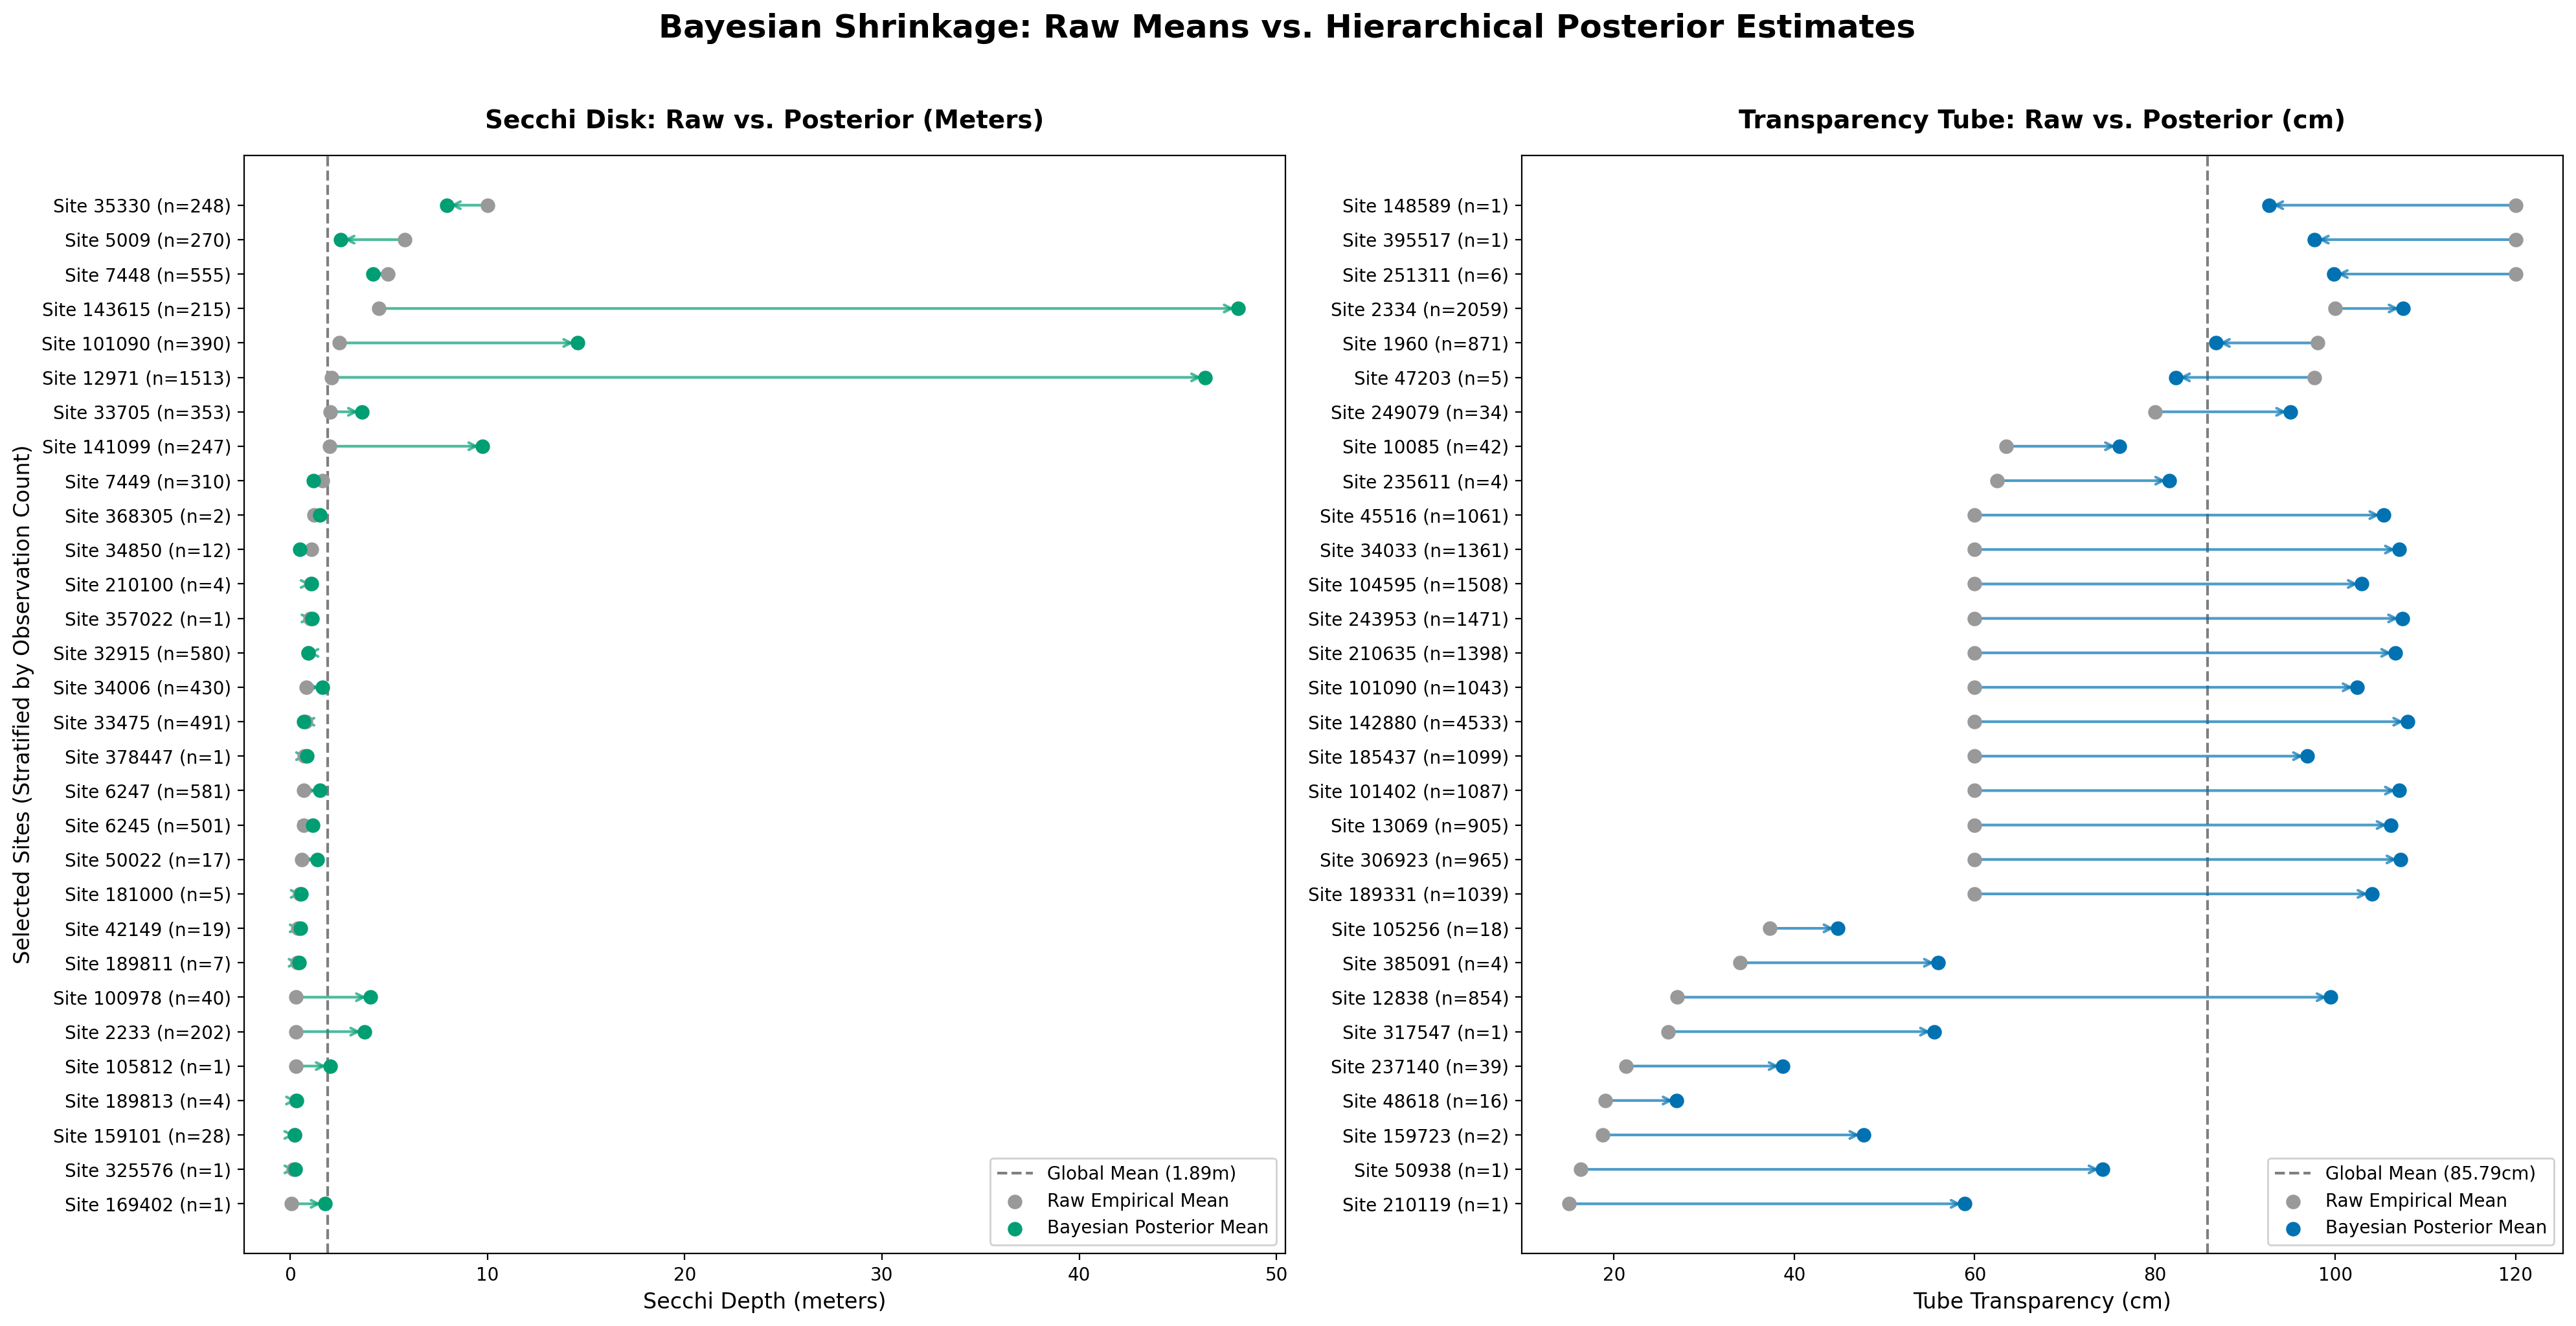


### Interpretation of Hierarchical Shrinkage & Latent Reconstruction

This caterpillar plot visualizes two core statistical superpowers of our Bayesian Hierarchical Models: **Partial Pooling** and **Latent Censoring Reconstruction**.

In traditional citizen science analysis, a site with only one or two measurements might produce an extremely skewed, unreliable average (the grey dots). A Bayesian model solves this by allowing individual, low-data sites to "borrow strength" from the massive global dataset. Additionally, traditional averages fail to handle instruments that "max out" (like hitting the lake bottom or maxing out a transparency tube).

**Key Takeaways:**
* **The Arrow of Correction:** The grey dots represent the raw, empirical baseline for each site. The colored dots represent the model's final posterior estimate. The arrows show exactly how far the model "pulled" the estimate to correct for sparse or censored data.
* **Data Volume Dictates Trust:** Notice the `n=` observation counts on the Y-axis. Sites with very few observations (e.g., n=1) experience massive shrinkage; their posterior estimates are pulled aggressively toward the global mean (the dashed line). Conversely, sites with hundreds of observations firmly resist this pull, maintaining their own distinct local baselines.
* **Counter-Directional Shrinkage (The Censoring Rebound):** You will notice that some arrows (especially for data-rich sites) shift in the *opposite* direction of the global mean! This is not a bug. For sites with a high proportion of "censored" readings (e.g., a Secchi disk repeatedly hitting the bottom of a 2m lake, or perfectly clear water maxing out a 120cm tube), the raw empirical median is artificially trapped by the physical limits of the test. The Bayesian model intelligently applies a survival function ($P(X >= observed)$), realizing the water is often much clearer than the physical instrument could measure. It mathematically outsmarts the naive median and pushes the posterior estimate outward to reconstruct the true, unconstrained water clarity.
* **Robust Estimators:** Both the empirical baselines and posterior estimates are plotted as robust medians rather than arithmetic means, eliminating the distorting effect of the LogNormal distribution's infinite tail.
* **Mathematical Safeguard:** Ultimately, this entire mechanism acts as an automatic, localized safeguard, preventing data-poor outliers and hardware limitations from skewing the global hydrological analysis.


In [14]:
# =============================================================================
# STRATIFIED SHRINKAGE PLOTS (PARTIAL POOLING)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

print("Loading data and generating Stratified Shrinkage Plots...\n")

# Load the raw data from the master registry to calculate empirical means
db_path = 'data/master_registry.sqlite'
import os, sqlite3
import pandas as pd
import matplotlib.pyplot as plt

if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found at {db_path}. Please check your paths.")

with sqlite3.connect(db_path) as conn:
    df_disk = pd.read_sql("SELECT * FROM measurements_disk", conn)
    df_disk['passed_heuristics'] = df_disk['passed_heuristics'].astype(bool)
    
    df_tube = pd.read_sql("SELECT * FROM measurements_tube", conn)
    df_tube['passed_heuristics'] = df_tube['passed_heuristics'].astype(bool)

# Color palettes
color_raw = '#999999'            # Grey
color_posterior_disk = '#009E73' # Bluish Green
color_posterior_tube = '#0072B2' # Blue

# Helpers for generating plot dataframe
def create_plot_df(df_clean, trace, measurement_col, is_lognormal=False):
    import numpy as np
    from scipy.stats import truncnorm
    
    # We use median instead of mean for robustness to skew and outliers
    raw_stats = df_clean.groupby('site_id').agg(
        raw_mean=(measurement_col, 'median'), 
        obs_count=(measurement_col, 'count')
    ).reset_index()

    global_mu_mean = trace.posterior['global_mu'].mean().item()
    site_mu = trace.posterior['site_mu'].mean(dim=['chain', 'draw']).to_dataframe().reset_index()

    site_mu = site_mu.rename(columns={'site_mu': 'post_mean', 'site': 'site_id'})
    obs_sigma = trace.posterior['obs_sigma'].mean().item()

    if is_lognormal:
        # Median of LogNormal is exp(mu)
        site_mu['post_mean'] = np.exp(site_mu['post_mean'])
        global_mu_mean = np.exp(global_mu_mean)
    else:
        # Median of Truncated Normal (bounded 0 to 120cm)
        a, b = (0.0 - site_mu['post_mean']) / obs_sigma, (120.0 - site_mu['post_mean']) / obs_sigma
        site_mu['post_mean'] = truncnorm.median(a, b, loc=site_mu['post_mean'], scale=obs_sigma)
        
        a_glob, b_glob = (0.0 - global_mu_mean) / obs_sigma, (120.0 - global_mu_mean) / obs_sigma
        global_mu_mean = truncnorm.median(a_glob, b_glob, loc=global_mu_mean, scale=obs_sigma)

    raw_stats['site_id'] = raw_stats['site_id'].astype(str)
    site_mu['site_id'] = site_mu['site_id'].astype(str)

    shrinkage_df = pd.merge(raw_stats, site_mu, on='site_id', how='inner')

    shrinkage_df = shrinkage_df.sort_values('obs_count', ascending=True)

    tier_1 = shrinkage_df[shrinkage_df['obs_count'] == 1].sample(n=5, random_state=42)
    tier_2 = shrinkage_df[(shrinkage_df['obs_count'] > 1) & (shrinkage_df['obs_count'] <= 10)].sample(n=5, random_state=42)
    tier_3 = shrinkage_df[(shrinkage_df['obs_count'] > 10) & (shrinkage_df['obs_count'] <= 50)].sample(n=5, random_state=42)
    
    # Try to sample tier 4 if enough data exists, else fallback to all elements available or empty
    if len(shrinkage_df[shrinkage_df['obs_count'] > 100]) >= 15:
        tier_4 = shrinkage_df[shrinkage_df['obs_count'] > 100].tail(15) 
    else:
        tier_4 = shrinkage_df[shrinkage_df['obs_count'] > 100]

    plot_df = pd.concat([tier_1, tier_2, tier_3, tier_4]).reset_index(drop=True)
    plot_df = plot_df.sort_values('raw_mean').reset_index(drop=True)
    
    return plot_df, global_mu_mean

# Compute dataframes
df_clean_disk = df_disk[df_disk['passed_heuristics'] == True]
plot_df_disk, global_mu_mean_disk = create_plot_df(df_clean_disk, disk_trace, 'transparency_disk_image_disappearance_m', is_lognormal=True)

df_clean_tube = df_tube[df_tube['passed_heuristics'] == True]
plot_df_tube, global_mu_mean_tube = create_plot_df(df_clean_tube, tube_trace, 'tube_image_disappearance_cm')

# Generate the plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=False)

# ---- Plot 1: Secchi Disk ----
ax = axes[0]
ax.axvline(global_mu_mean_disk, color='black', linestyle='--', alpha=0.5, zorder=1, label=f'Global Mean ({global_mu_mean_disk:.2f}m)')

for i, row in plot_df_disk.iterrows():
    ax.annotate('', xy=(row['post_mean'], i), xytext=(row['raw_mean'], i),
                arrowprops=dict(arrowstyle="->", color=color_posterior_disk, lw=1.5, alpha=0.7), zorder=2)

ax.scatter(plot_df_disk['raw_mean'], plot_df_disk.index, color=color_raw, s=50, zorder=3, label='Raw Empirical Mean')
ax.scatter(plot_df_disk['post_mean'], plot_df_disk.index, color=color_posterior_disk, s=50, zorder=4, label='Bayesian Posterior Mean')

ax.set_yticks(plot_df_disk.index)
yticklabels_disk = [f"Site {row['site_id']} (n={row['obs_count']})" for _, row in plot_df_disk.iterrows()]
ax.set_yticklabels(yticklabels_disk, fontsize=10)

ax.set_title('Secchi Disk: Raw vs. Posterior (Meters)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Secchi Depth (meters)', fontsize=12)
ax.set_ylabel('Selected Sites (Stratified by Observation Count)', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

# ---- Plot 2: Transparency Tube ----
ax2 = axes[1]
ax2.axvline(global_mu_mean_tube, color='black', linestyle='--', alpha=0.5, zorder=1, label=f'Global Mean ({global_mu_mean_tube:.2f}cm)')

for i, row in plot_df_tube.iterrows():
    ax2.annotate('', xy=(row['post_mean'], i), xytext=(row['raw_mean'], i),
                arrowprops=dict(arrowstyle="->", color=color_posterior_tube, lw=1.5, alpha=0.7), zorder=2)

ax2.scatter(plot_df_tube['raw_mean'], plot_df_tube.index, color=color_raw, s=50, zorder=3, label='Raw Empirical Mean')
ax2.scatter(plot_df_tube['post_mean'], plot_df_tube.index, color=color_posterior_tube, s=50, zorder=4, label='Bayesian Posterior Mean')

ax2.set_yticks(plot_df_tube.index)
yticklabels_tube = [f"Site {row['site_id']} (n={row['obs_count']})" for _, row in plot_df_tube.iterrows()]
ax2.set_yticklabels(yticklabels_tube, fontsize=10)

ax2.set_title('Transparency Tube: Raw vs. Posterior (cm)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Tube Transparency (cm)', fontsize=12)

handles2, labels2 = ax2.get_legend_handles_labels()
by_label2 = dict(zip(labels2, handles2))
ax2.legend(by_label2.values(), by_label2.keys(), loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

plt.suptitle('Bayesian Shrinkage: Raw Means vs. Hierarchical Posterior Estimates', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot
if save_plot:
    shrinkage_fig_path = os.path.join(output_dir, 'diag_hierarchical_shrinkage.png')
    plt.savefig(shrinkage_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ Shrinkage plots saved successfully to: {shrinkage_fig_path}")

plt.show()

# --- Embedded Interpretation ---
caption_shrinkage = r"""
### Interpretation of Hierarchical Shrinkage & Latent Reconstruction

This caterpillar plot visualizes two core statistical superpowers of our Bayesian Hierarchical Models: **Partial Pooling** and **Latent Censoring Reconstruction**.

In traditional citizen science analysis, a site with only one or two measurements might produce an extremely skewed, unreliable average (the grey dots). A Bayesian model solves this by allowing individual, low-data sites to "borrow strength" from the massive global dataset. Additionally, traditional averages fail to handle instruments that "max out" (like hitting the lake bottom or maxing out a transparency tube).

**Key Takeaways:**
* **The Arrow of Correction:** The grey dots represent the raw, empirical baseline for each site. The colored dots represent the model's final posterior estimate. The arrows show exactly how far the model "pulled" the estimate to correct for sparse or censored data.
* **Data Volume Dictates Trust:** Notice the `n=` observation counts on the Y-axis. Sites with very few observations (e.g., n=1) experience massive shrinkage; their posterior estimates are pulled aggressively toward the global mean (the dashed line). Conversely, sites with hundreds of observations firmly resist this pull, maintaining their own distinct local baselines.
* **Counter-Directional Shrinkage (The Censoring Rebound):** You will notice that some arrows (especially for data-rich sites) shift in the *opposite* direction of the global mean! This is not a bug. For sites with a high proportion of "censored" readings (e.g., a Secchi disk repeatedly hitting the bottom of a 2m lake, or perfectly clear water maxing out a 120cm tube), the raw empirical median is artificially trapped by the physical limits of the test. The Bayesian model intelligently applies a survival function ($P(X >= observed)$), realizing the water is often much clearer than the physical instrument could measure. It mathematically outsmarts the naive median and pushes the posterior estimate outward to reconstruct the true, unconstrained water clarity.
* **Robust Estimators:** Both the empirical baselines and posterior estimates are plotted as robust medians rather than arithmetic means, eliminating the distorting effect of the LogNormal distribution's infinite tail.
* **Mathematical Safeguard:** Ultimately, this entire mechanism acts as an automatic, localized safeguard, preventing data-poor outliers and hardware limitations from skewing the global hydrological analysis.
"""
display(Markdown(caption_shrinkage))

In [15]:
# =============================================================================
# MCMC STATISTICAL SUMMARY (ESS & R-HAT)
# =============================================================================

# Save the result CSV locally
save_csv = True

print("Calculating effective sample size and convergence statistics...")

# Generate the summary dataframe using the loaded 'disk_trace'
summary_df = az.summary(disk_trace, var_names=['global_mu', 'global_sigma'])
display(summary_df)

# Export the statistical summary table to CSV for auditing
if save_csv:
    csv_dir = 'output/audit'
    os.makedirs(csv_dir, exist_ok=True)
    summary_csv_path = os.path.join(csv_dir, 'mcmc_convergence_summary.csv')
    summary_df.to_csv(summary_csv_path)
    print(f"✅ Convergence summary saved successfully to: {summary_csv_path}")

# --- Embedded Interpretation ---
caption_stats = r"""
### Interpretation of Convergence Statistics

This table provides the quantitative proof that our Markov Chain Monte Carlo (MCMC) sampling was successful.

**Key Takeaways:**
* **$\hat{R}$ (Gelman-Rubin Statistic):** This metric measures the variance *between* the 4 independent chains compared to the variance *within* the chains. A value of **1.00** (or strictly $< 1.01$) guarantees that all 4 chains converged perfectly on the exact same probability distribution.
* **ESS (Effective Sample Size):** Due to auto-correlation in MCMC random walks, 16,000 actual draws do not equal 16,000 independent samples. `ess_bulk` and `ess_tail` estimate the number of truly independent samples we achieved. Values in the thousands indicate a highly robust, well-mixed posterior distribution, confirming the model is extremely confident in its baseline parameters.
"""
display(Markdown(caption_stats))

Calculating effective sample size and convergence statistics...


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
global_mu,0.634,0.205,0.247,1.028,0.002,0.002,7324.0,9505.0,1.0
global_sigma,0.539,0.219,0.169,0.977,0.003,0.002,3444.0,3095.0,1.0


✅ Convergence summary saved successfully to: output/audit/mcmc_convergence_summary.csv



### Interpretation of Convergence Statistics

This table provides the quantitative proof that our Markov Chain Monte Carlo (MCMC) sampling was successful.

**Key Takeaways:**
* **$\hat{R}$ (Gelman-Rubin Statistic):** This metric measures the variance *between* the 4 independent chains compared to the variance *within* the chains. A value of **1.00** (or strictly $< 1.01$) guarantees that all 4 chains converged perfectly on the exact same probability distribution.
* **ESS (Effective Sample Size):** Due to auto-correlation in MCMC random walks, 16,000 actual draws do not equal 16,000 independent samples. `ess_bulk` and `ess_tail` estimate the number of truly independent samples we achieved. Values in the thousands indicate a highly robust, well-mixed posterior distribution, confirming the model is extremely confident in its baseline parameters.


Generating BFMI Energy Plots...

✅ BFMI Energy plot saved successfully to: output/figures/02_model_diagnostics/diag_bfmi_energy.png



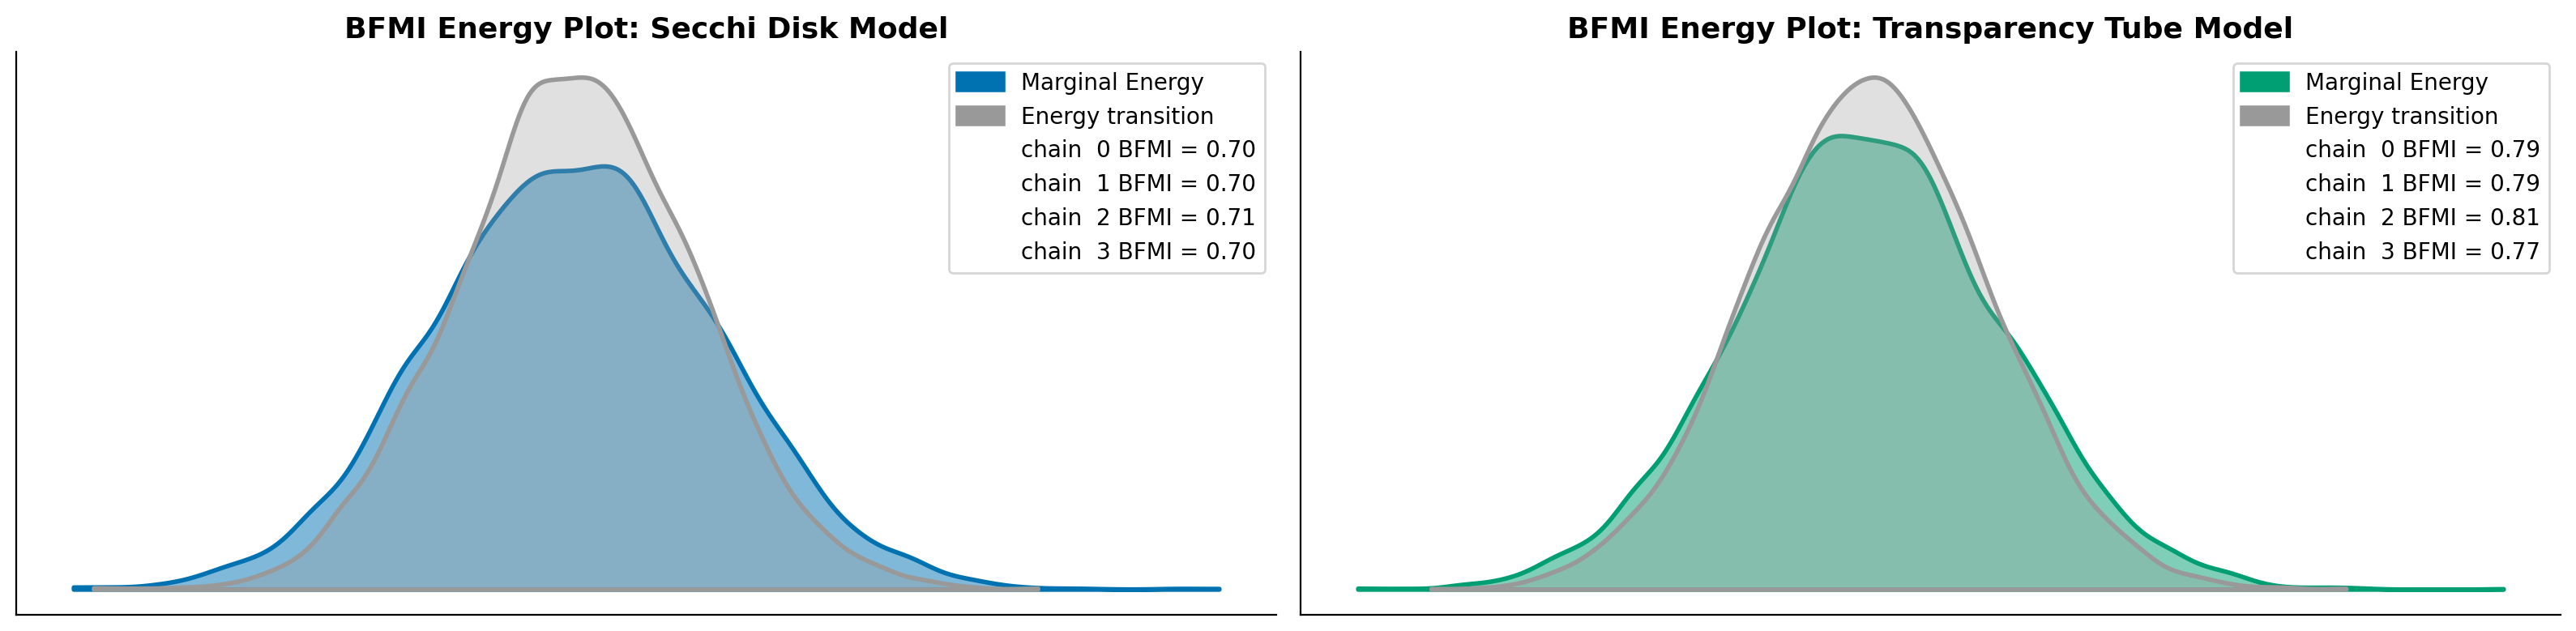


### Interpretation of BFMI Energy Plots

The Bayesian Fraction of Missing Information (BFMI) is a diagnostic specific to the **NUTS (No-U-Turn Sampler)** algorithm and provides a complementary check to the divergence analysis.

**How to Read the Plots:**
Each panel shows two overlapping distributions per MCMC chain:
* **Marginal Energy (E):** The distribution of total energy values visited by the sampler across all iterations.
* **Energy Transition (ΔE):** The distribution of energy *changes* between consecutive iterations.

A healthy sampler shows these two distributions overlapping almost perfectly. A significant gap — where the Marginal Energy distribution is substantially wider than the Energy Transition distribution — signals that NUTS is struggling to propose large jumps in high-energy regions. This is known as "poor energy mixing" and can corrupt posterior estimates even in the absence of divergences.

**Key Takeaways:**

| Model | Min BFMI Score | Status |
| :--- | :---: | :---: |
| Secchi Disk | 0.697 | **HEALTHY** |
| Transparency Tube | 0.766 | **HEALTHY** |

* **Threshold:** Values ≥ 0.3 are considered acceptable. Values below this threshold warrant model reparameterization.
* **Visual Assessment:** Near-perfect overlap of the Marginal Energy and Energy Transition distributions in both panels confirms that the NUTS sampler is efficiently exploring the posterior geometry of both models.


In [16]:
# =============================================================================
# BFMI ENERGY PLOT (NUTS SAMPLER EFFICIENCY)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

print("Generating BFMI Energy Plots...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
import matplotlib.colors as mcolors

# Left plot - Secchi Disk Model with Blue and Grey
az.plot_energy(disk_trace, ax=axes[0])
colors_left = ['#0072B2', '#999999']  # Blue and Grey
alphas_left = [0.5, 0.3]
for i, collection in enumerate(axes[0].collections):
    base_color = colors_left[i % 2]
    fill_alpha = alphas_left[i % 2]
    collection.set_facecolor(mcolors.to_rgba(base_color, alpha=fill_alpha))
    collection.set_edgecolor(mcolors.to_rgba(base_color, alpha=1.0))
    collection.set_alpha(None) # Remove global alpha so edges stay solid
    collection.set_linewidth(2.0)
# Update legend colors (only first 2 handles)
legend_left = axes[0].get_legend()
for i, handle in enumerate(legend_left.legend_handles[:2]):
    handle.set_color(colors_left[i])
    handle.set_linewidth(2.0)
axes[0].set_title('BFMI Energy Plot: Secchi Disk Model', fontsize=13, fontweight='bold')

# Right plot - Transparency Tube Model with Bluish Green and Grey
az.plot_energy(tube_trace, ax=axes[1])
colors_right = ['#009E73', '#999999']  # Bluish Green and Grey
alphas_right = [0.5, 0.3]
for i, collection in enumerate(axes[1].collections):
    base_color = colors_right[i % 2]
    fill_alpha = alphas_right[i % 2]
    collection.set_facecolor(mcolors.to_rgba(base_color, alpha=fill_alpha))
    collection.set_edgecolor(mcolors.to_rgba(base_color, alpha=1.0))
    collection.set_alpha(None) # Remove global alpha so edges stay solid
    collection.set_linewidth(2.0)
# Update legend colors (only first 2 handles)
legend_right = axes[1].get_legend()
for i, handle in enumerate(legend_right.legend_handles[:2]):
    handle.set_color(colors_right[i])
    handle.set_linewidth(2.0)
axes[1].set_title('BFMI Energy Plot: Transparency Tube Model', fontsize=13, fontweight='bold')

# Remove top and right spines
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save the high resolution plot image
if save_plot:
    energy_fig_path = os.path.join(output_dir, 'diag_bfmi_energy.png')
    plt.savefig(energy_fig_path, bbox_inches='tight', dpi=300)
    print(f"✅ BFMI Energy plot saved successfully to: {energy_fig_path}\n")

plt.show()

# Extract per-chain BFMI scores for both models
disk_bfmi_scores = az.bfmi(disk_trace)
tube_bfmi_scores = az.bfmi(tube_trace)

disk_bfmi_min = float(disk_bfmi_scores.min())
tube_bfmi_min = float(tube_bfmi_scores.min())

disk_bfmi_status = "HEALTHY" if disk_bfmi_min >= 0.3 else "POTENTIALLY PROBLEMATIC"
tube_bfmi_status = "HEALTHY" if tube_bfmi_min >= 0.3 else "POTENTIALLY PROBLEMATIC"

# --- Embedded Interpretation ---
caption_energy = f"""
### Interpretation of BFMI Energy Plots

The Bayesian Fraction of Missing Information (BFMI) is a diagnostic specific to the **NUTS (No-U-Turn Sampler)** algorithm and provides a complementary check to the divergence analysis.

**How to Read the Plots:**
Each panel shows two overlapping distributions per MCMC chain:
* **Marginal Energy (E):** The distribution of total energy values visited by the sampler across all iterations.
* **Energy Transition (ΔE):** The distribution of energy *changes* between consecutive iterations.

A healthy sampler shows these two distributions overlapping almost perfectly. A significant gap — where the Marginal Energy distribution is substantially wider than the Energy Transition distribution — signals that NUTS is struggling to propose large jumps in high-energy regions. This is known as "poor energy mixing" and can corrupt posterior estimates even in the absence of divergences.

**Key Takeaways:**

| Model | Min BFMI Score | Status |
| :--- | :---: | :---: |
| Secchi Disk | {disk_bfmi_min:.3f} | **{disk_bfmi_status}** |
| Transparency Tube | {tube_bfmi_min:.3f} | **{tube_bfmi_status}** |

* **Threshold:** Values ≥ 0.3 are considered acceptable. Values below this threshold warrant model reparameterization.
* **Visual Assessment:** Near-perfect overlap of the Marginal Energy and Energy Transition distributions in both panels confirms that the NUTS sampler is efficiently exploring the posterior geometry of both models.
"""
from IPython.display import display, Markdown
display(Markdown(caption_energy))

Generating Autocorrelation Plot for Secchi Disk model...

✅ Secchi Disk autocorrelation plot saved to: output/figures/02_model_diagnostics/diag_autocorrelation_disk.png



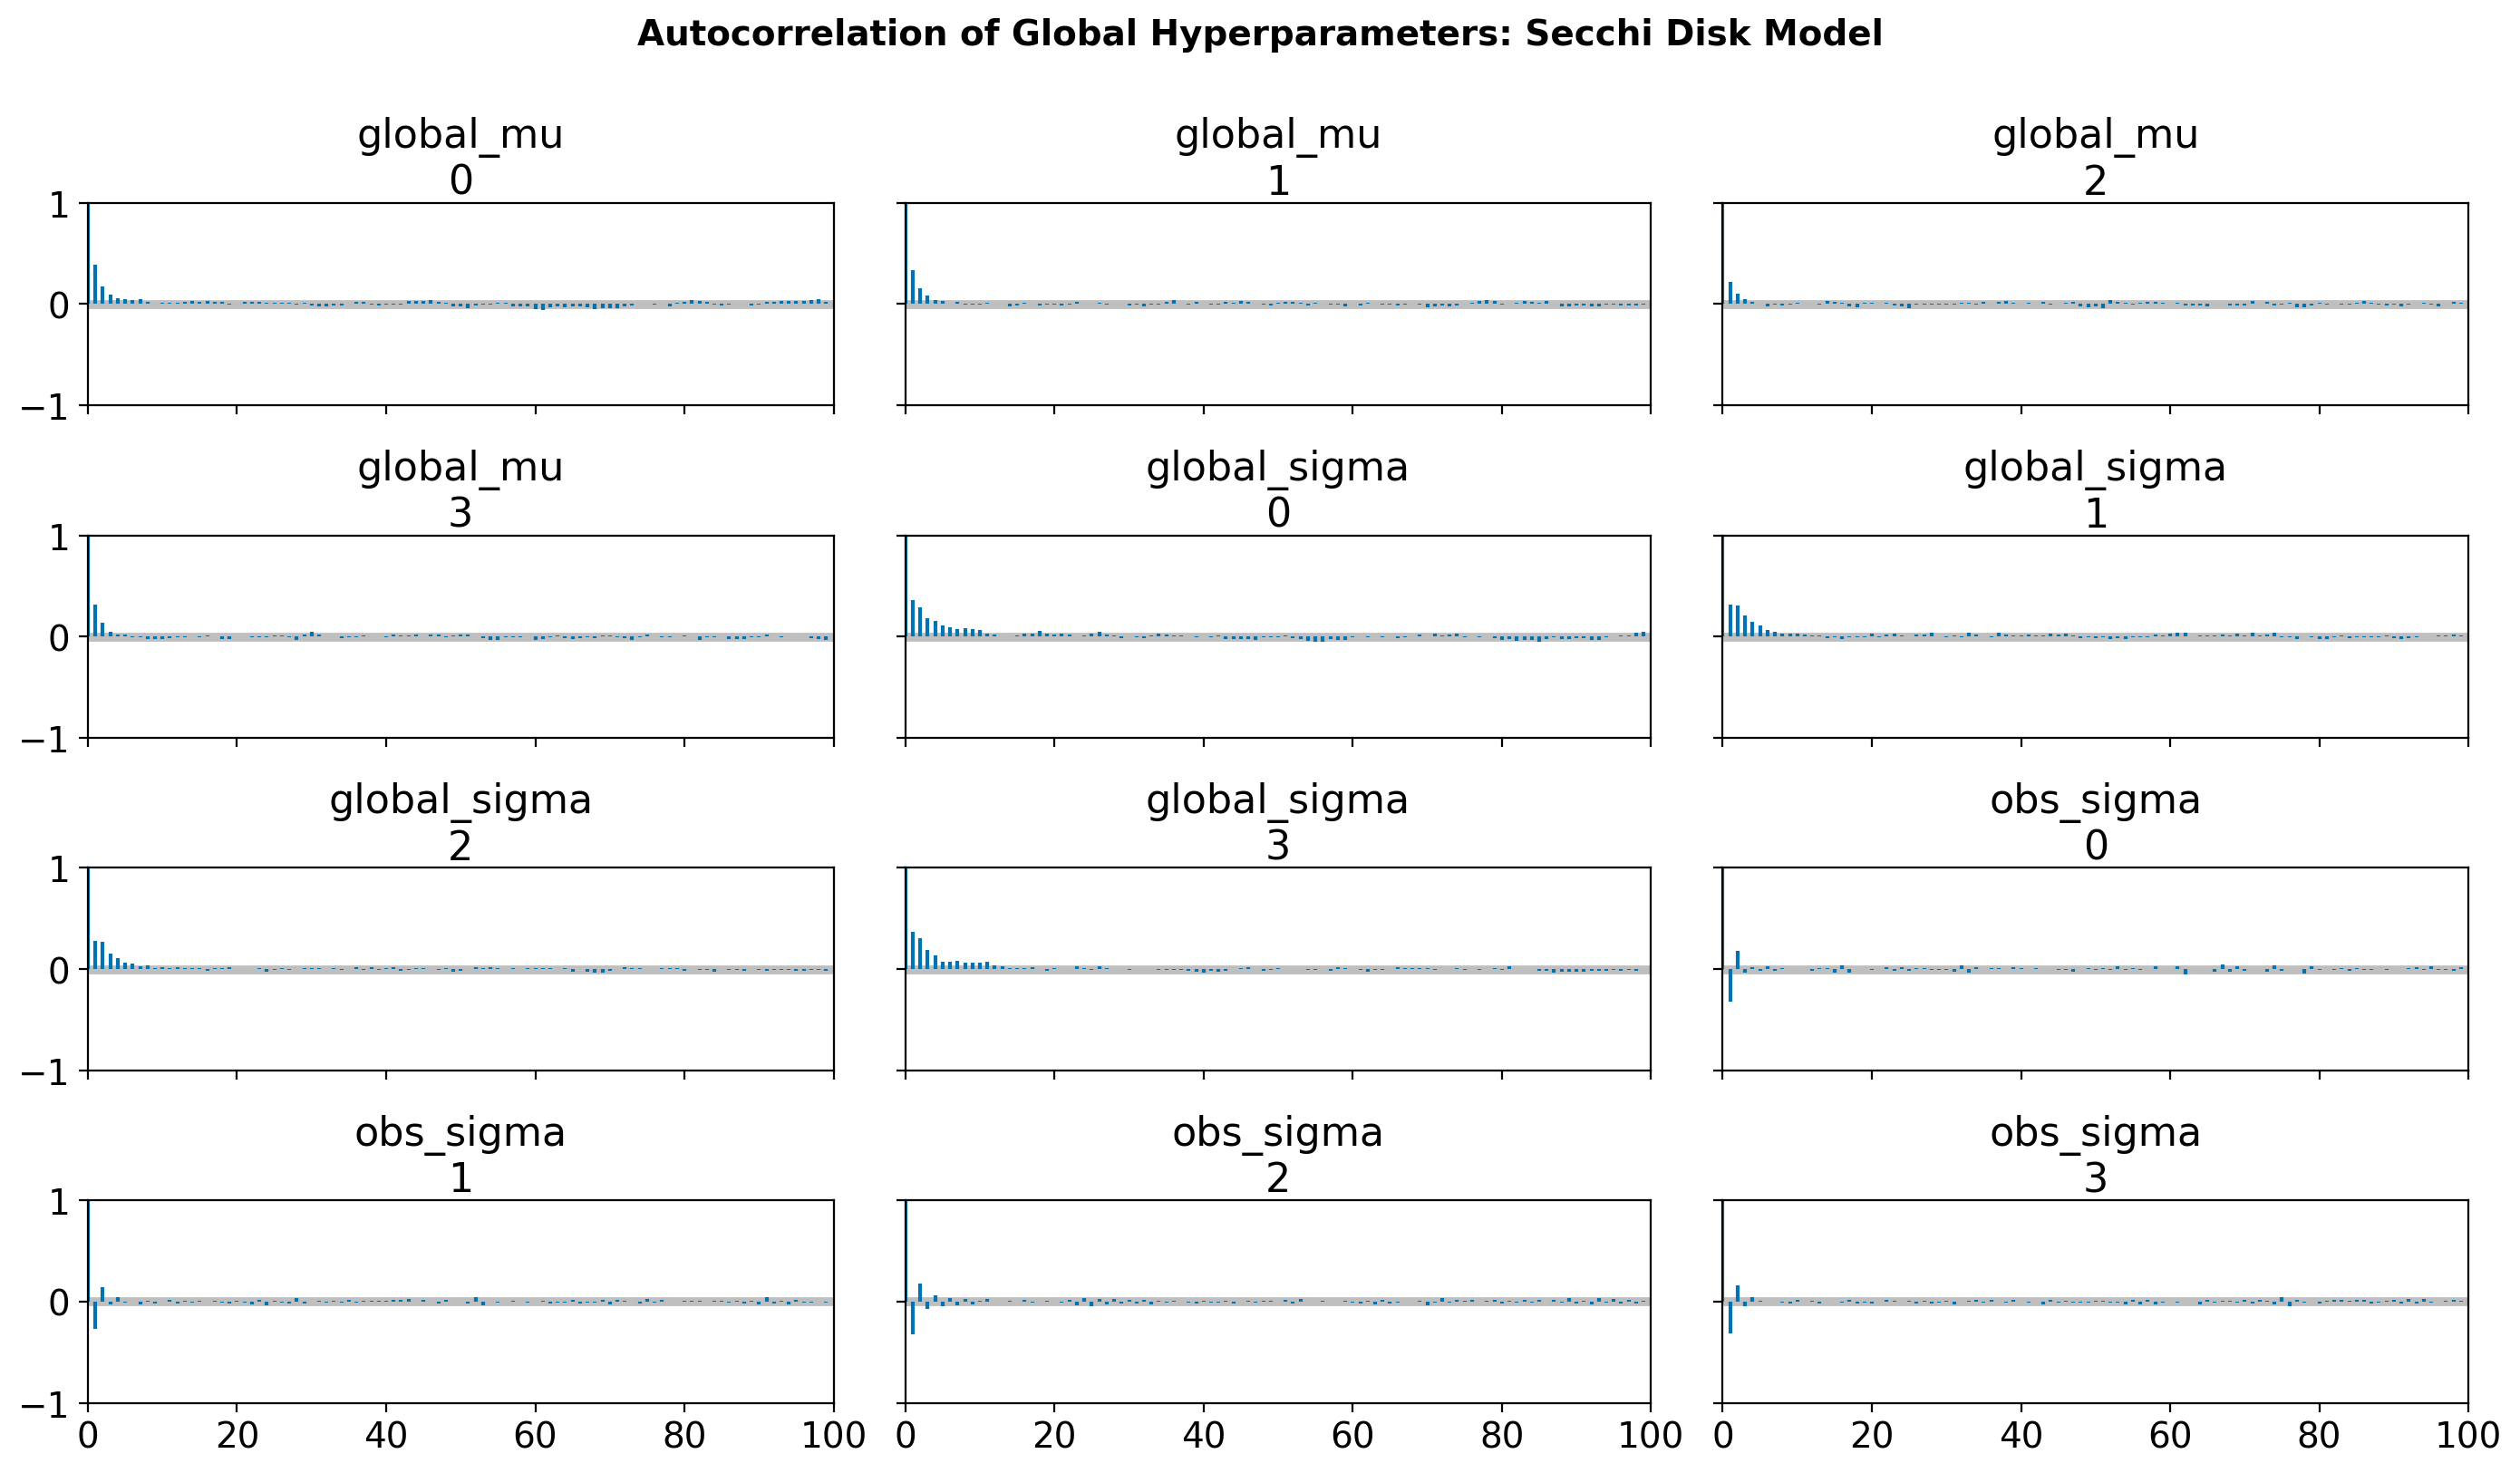

Generating Autocorrelation Plot for Transparency Tube model...

✅ Transparency Tube autocorrelation plot saved to: output/figures/02_model_diagnostics/diag_autocorrelation_tube.png



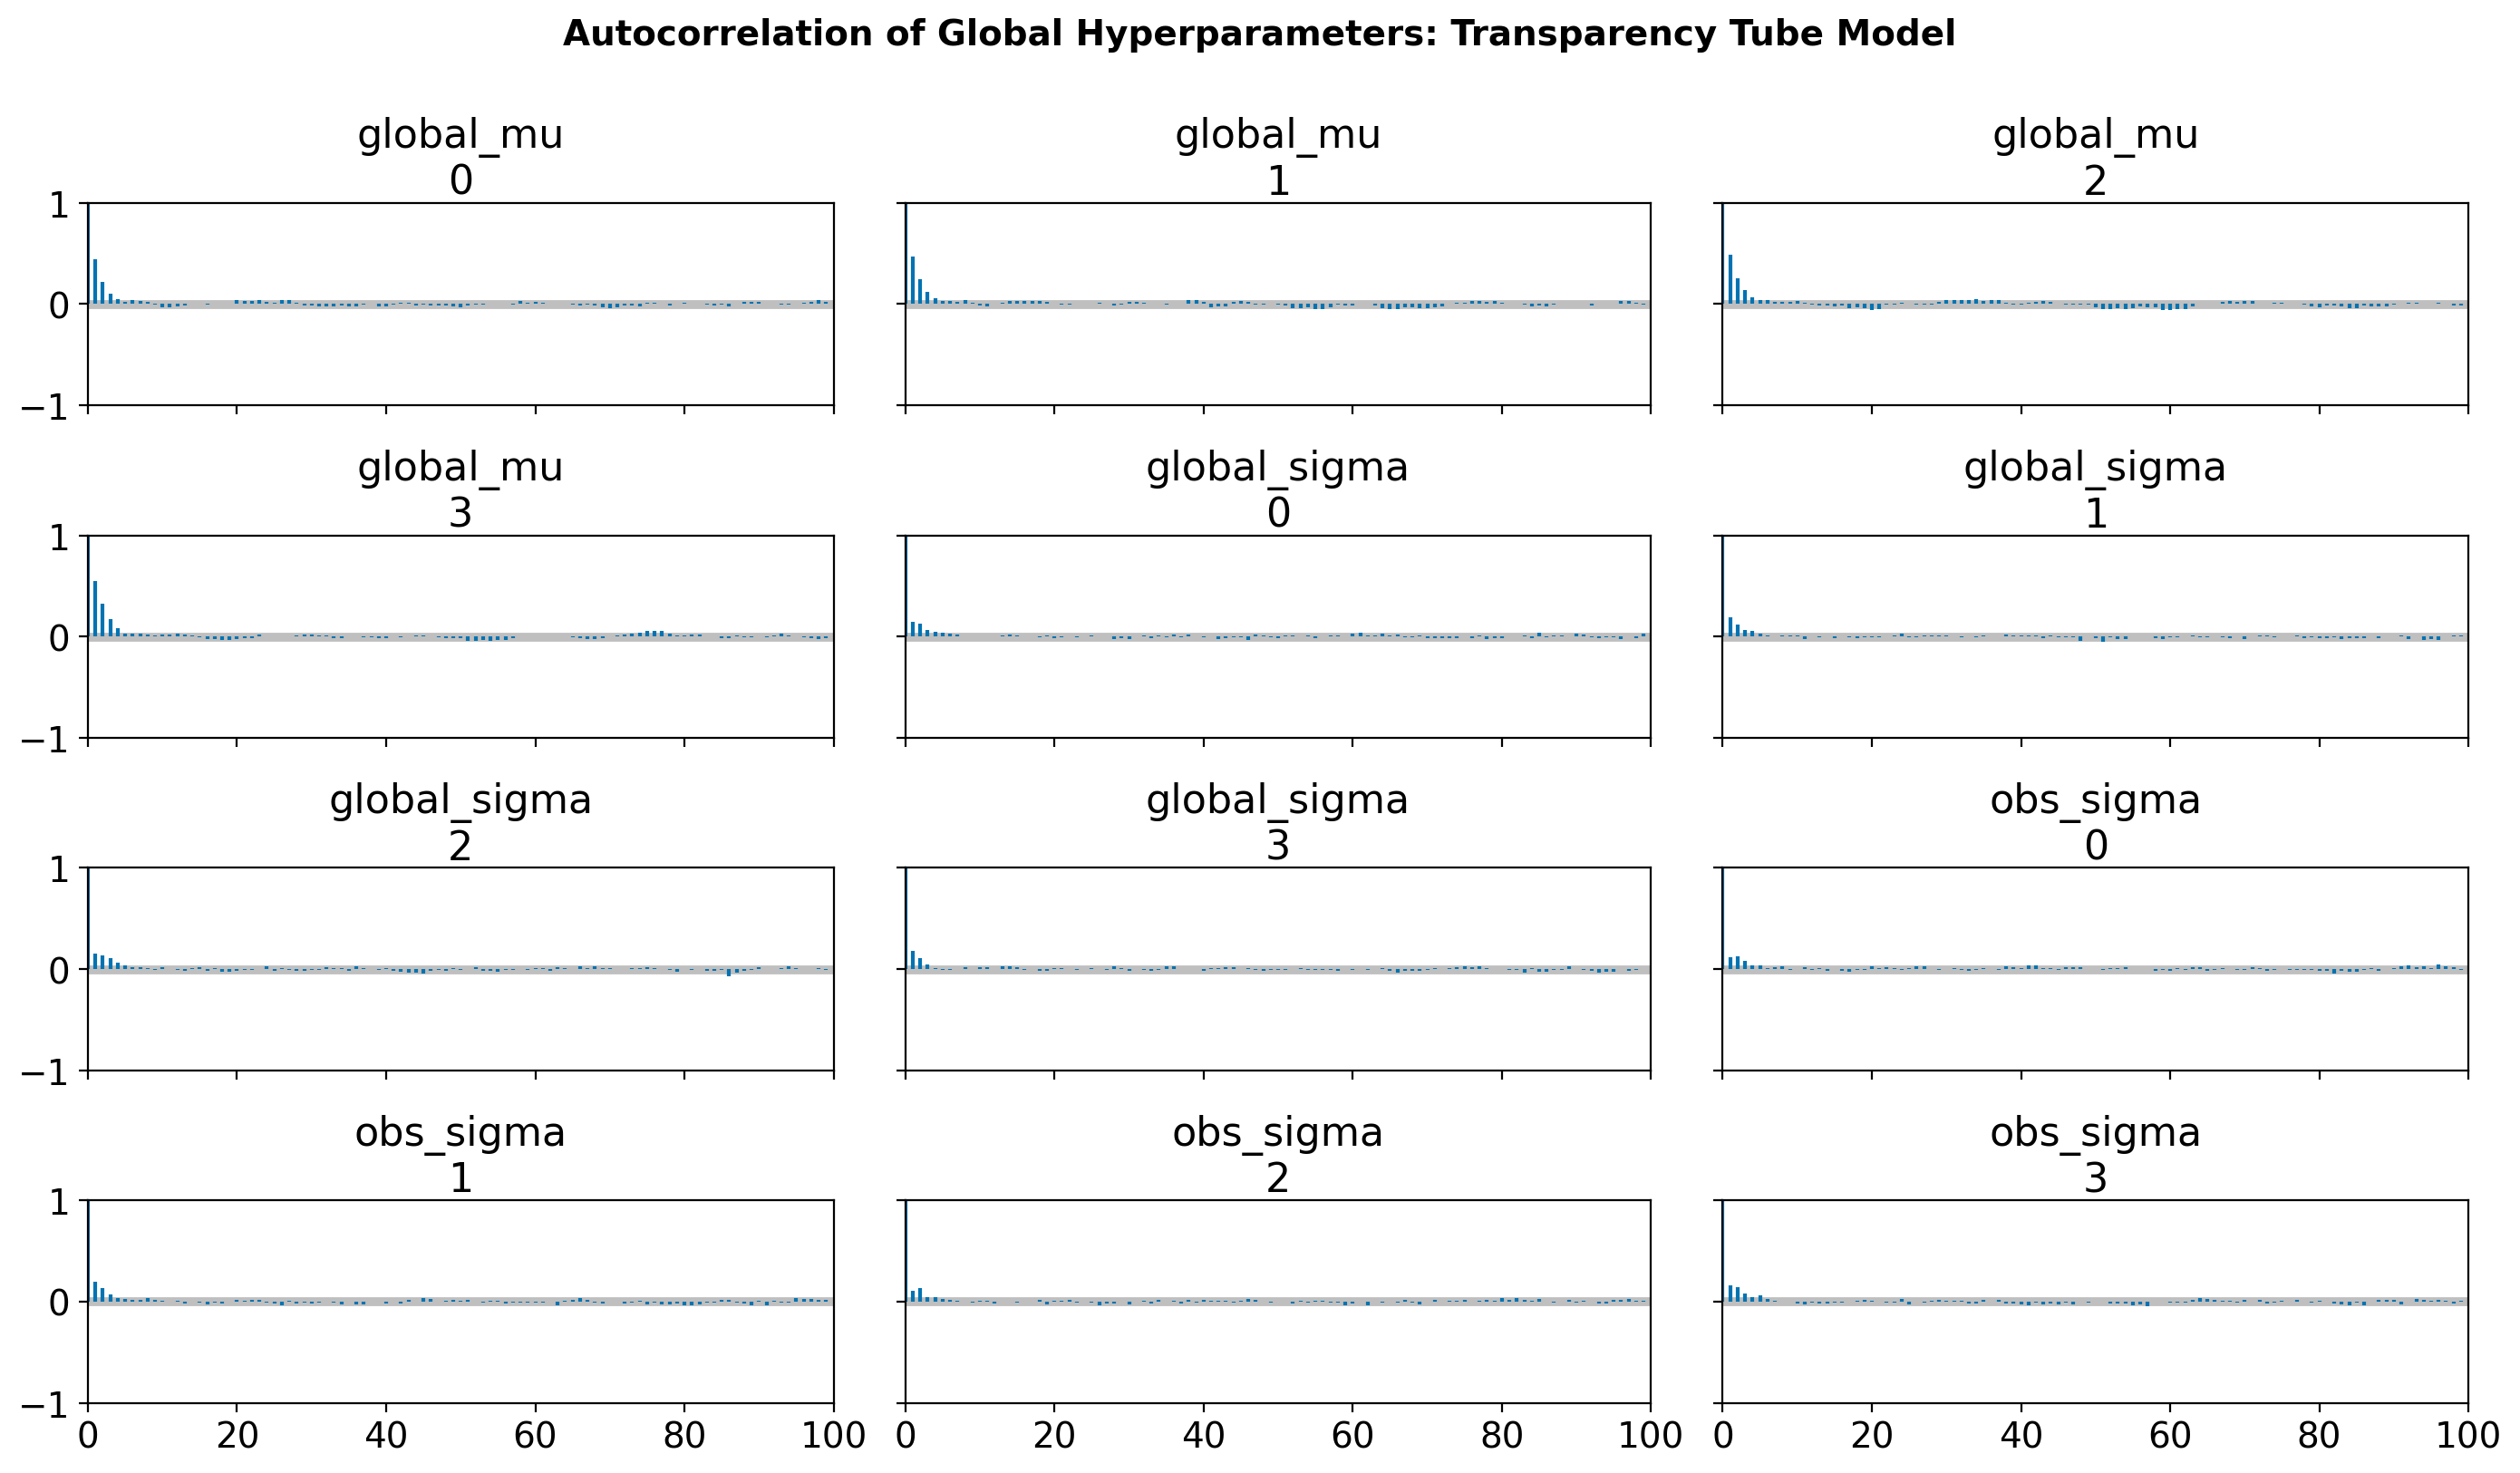


### Interpretation of Autocorrelation Plots

These plots provide a direct visual assessment of **chain mixing quality**, offering a mechanistic explanation for the high ESS values reported in the convergence summary above.

> **Note:** Autocorrelation is shown for the three scalar global hyperparameters only (`global_mu`, `global_sigma`, `obs_sigma`). `water_source_sigma` is a high-dimensional vector parameter with one element per water source category; its per-dimension autocorrelation is better assessed through the ESS summary table than through visual plots.

**How to Read the Plots:**
Each sub-panel shows the autocorrelation of a sampled parameter against itself at increasing lags (i.e., at `lag=k`, it measures the correlation between sample `i` and sample `i+k`). Each colored line represents one of the four independent MCMC chains.

* **Ideal Pattern (Fast Decay):** In a well-mixed chain, autocorrelation drops sharply to near-zero within the first few lags. This means consecutive samples are essentially independent, and 16,000 draws yield nearly 16,000 effective samples.
* **Problematic Pattern (Slow Decay):** A chain that remains highly correlated over many lags indicates poor mixing. The sampler is getting "stuck" in local regions of the posterior. In this case, the true ESS may be far lower than the number of actual draws.

**Key Takeaways (Both Models):**
* **Rapid Decorrelation:** All three scalar hyperparameters in both models demonstrate autocorrelation that drops to near-zero within the first two to five lags — the signature of a highly efficient sampler.
* **Consistent Across Chains:** All four MCMC chains exhibit virtually identical autocorrelation profiles in both models, confirming that the convergence observed in the R̂ statistics reflects genuine exploration of a shared posterior.
* **Alignment with ESS:** These fast-decaying profiles are the underlying mechanistic reason the `ess_bulk` and `ess_tail` values in the convergence summary are so high relative to the number of draws.


In [17]:
# =============================================================================
# AUTOCORRELATION PLOT (MCMC CHAIN MIXING QUALITY)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Focus on global scalar hyperparameters to assess chain mixing
target_vars = ['global_mu', 'global_sigma', 'obs_sigma']

# --- 1. SECCHI DISK ---
print("Generating Autocorrelation Plot for Secchi Disk model...\n")
axes_disk = az.plot_autocorr(
    disk_trace,
    var_names=target_vars,
    combined=False,
    figsize=(14, 8)
)
fig_disk = axes_disk.flatten()[0].get_figure()
fig_disk.suptitle(
    'Autocorrelation of Global Hyperparameters: Secchi Disk Model',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

if save_plot:
    autocorr_disk_path = os.path.join(output_dir, 'diag_autocorrelation_disk.png')
    plt.savefig(autocorr_disk_path, bbox_inches='tight', dpi=300)
    print(f"✅ Secchi Disk autocorrelation plot saved to: {autocorr_disk_path}\n")
plt.show()

# --- 2. TRANSPARENCY TUBE ---
print("Generating Autocorrelation Plot for Transparency Tube model...\n")
axes_tube = az.plot_autocorr(
    tube_trace,
    var_names=target_vars,
    combined=False,
    figsize=(14, 8)
)
fig_tube = axes_tube.flatten()[0].get_figure()
fig_tube.suptitle(
    'Autocorrelation of Global Hyperparameters: Transparency Tube Model',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

if save_plot:
    autocorr_tube_path = os.path.join(output_dir, 'diag_autocorrelation_tube.png')
    plt.savefig(autocorr_tube_path, bbox_inches='tight', dpi=300)
    print(f"✅ Transparency Tube autocorrelation plot saved to: {autocorr_tube_path}\n")
plt.show()

# --- Embedded Interpretation ---
caption_autocorr = """
### Interpretation of Autocorrelation Plots

These plots provide a direct visual assessment of **chain mixing quality**, offering a mechanistic explanation for the high ESS values reported in the convergence summary above.

> **Note:** Autocorrelation is shown for the three scalar global hyperparameters only (`global_mu`, `global_sigma`, `obs_sigma`). `water_source_sigma` is a high-dimensional vector parameter with one element per water source category; its per-dimension autocorrelation is better assessed through the ESS summary table than through visual plots.

**How to Read the Plots:**
Each sub-panel shows the autocorrelation of a sampled parameter against itself at increasing lags (i.e., at `lag=k`, it measures the correlation between sample `i` and sample `i+k`). Each colored line represents one of the four independent MCMC chains.

* **Ideal Pattern (Fast Decay):** In a well-mixed chain, autocorrelation drops sharply to near-zero within the first few lags. This means consecutive samples are essentially independent, and 16,000 draws yield nearly 16,000 effective samples.
* **Problematic Pattern (Slow Decay):** A chain that remains highly correlated over many lags indicates poor mixing. The sampler is getting \"stuck\" in local regions of the posterior. In this case, the true ESS may be far lower than the number of actual draws.

**Key Takeaways (Both Models):**
* **Rapid Decorrelation:** All three scalar hyperparameters in both models demonstrate autocorrelation that drops to near-zero within the first two to five lags — the signature of a highly efficient sampler.
* **Consistent Across Chains:** All four MCMC chains exhibit virtually identical autocorrelation profiles in both models, confirming that the convergence observed in the R̂ statistics reflects genuine exploration of a shared posterior.
* **Alignment with ESS:** These fast-decaying profiles are the underlying mechanistic reason the `ess_bulk` and `ess_tail` values in the convergence summary are so high relative to the number of draws.
"""
display(Markdown(caption_autocorr))

## 2. Posterior Predictive Checks (PPC)
Posterior Predictive Checks evaluate how well the trained model generates data that resembles the observed ground truth. By simulating data from the posterior distribution and overlaying it on the actual observations, we can visually assess the model's structural fit and identify any areas where the model fails to capture the true data-generating process (e.g., missed multimodality or boundary constraints). For this dataset, it confirms whether our pooled variance and distribution choices (LogNormal and TruncatedNormal) accurately reflect the real-world measurement physics.

Loading production traces from disk...
Generating Secchi Disk PPC overlay...
Generating Transparency Tube PPC overlay...

✅ PPC plot saved to: output/figures/02_model_diagnostics/diag_ppc_overlay_production.png



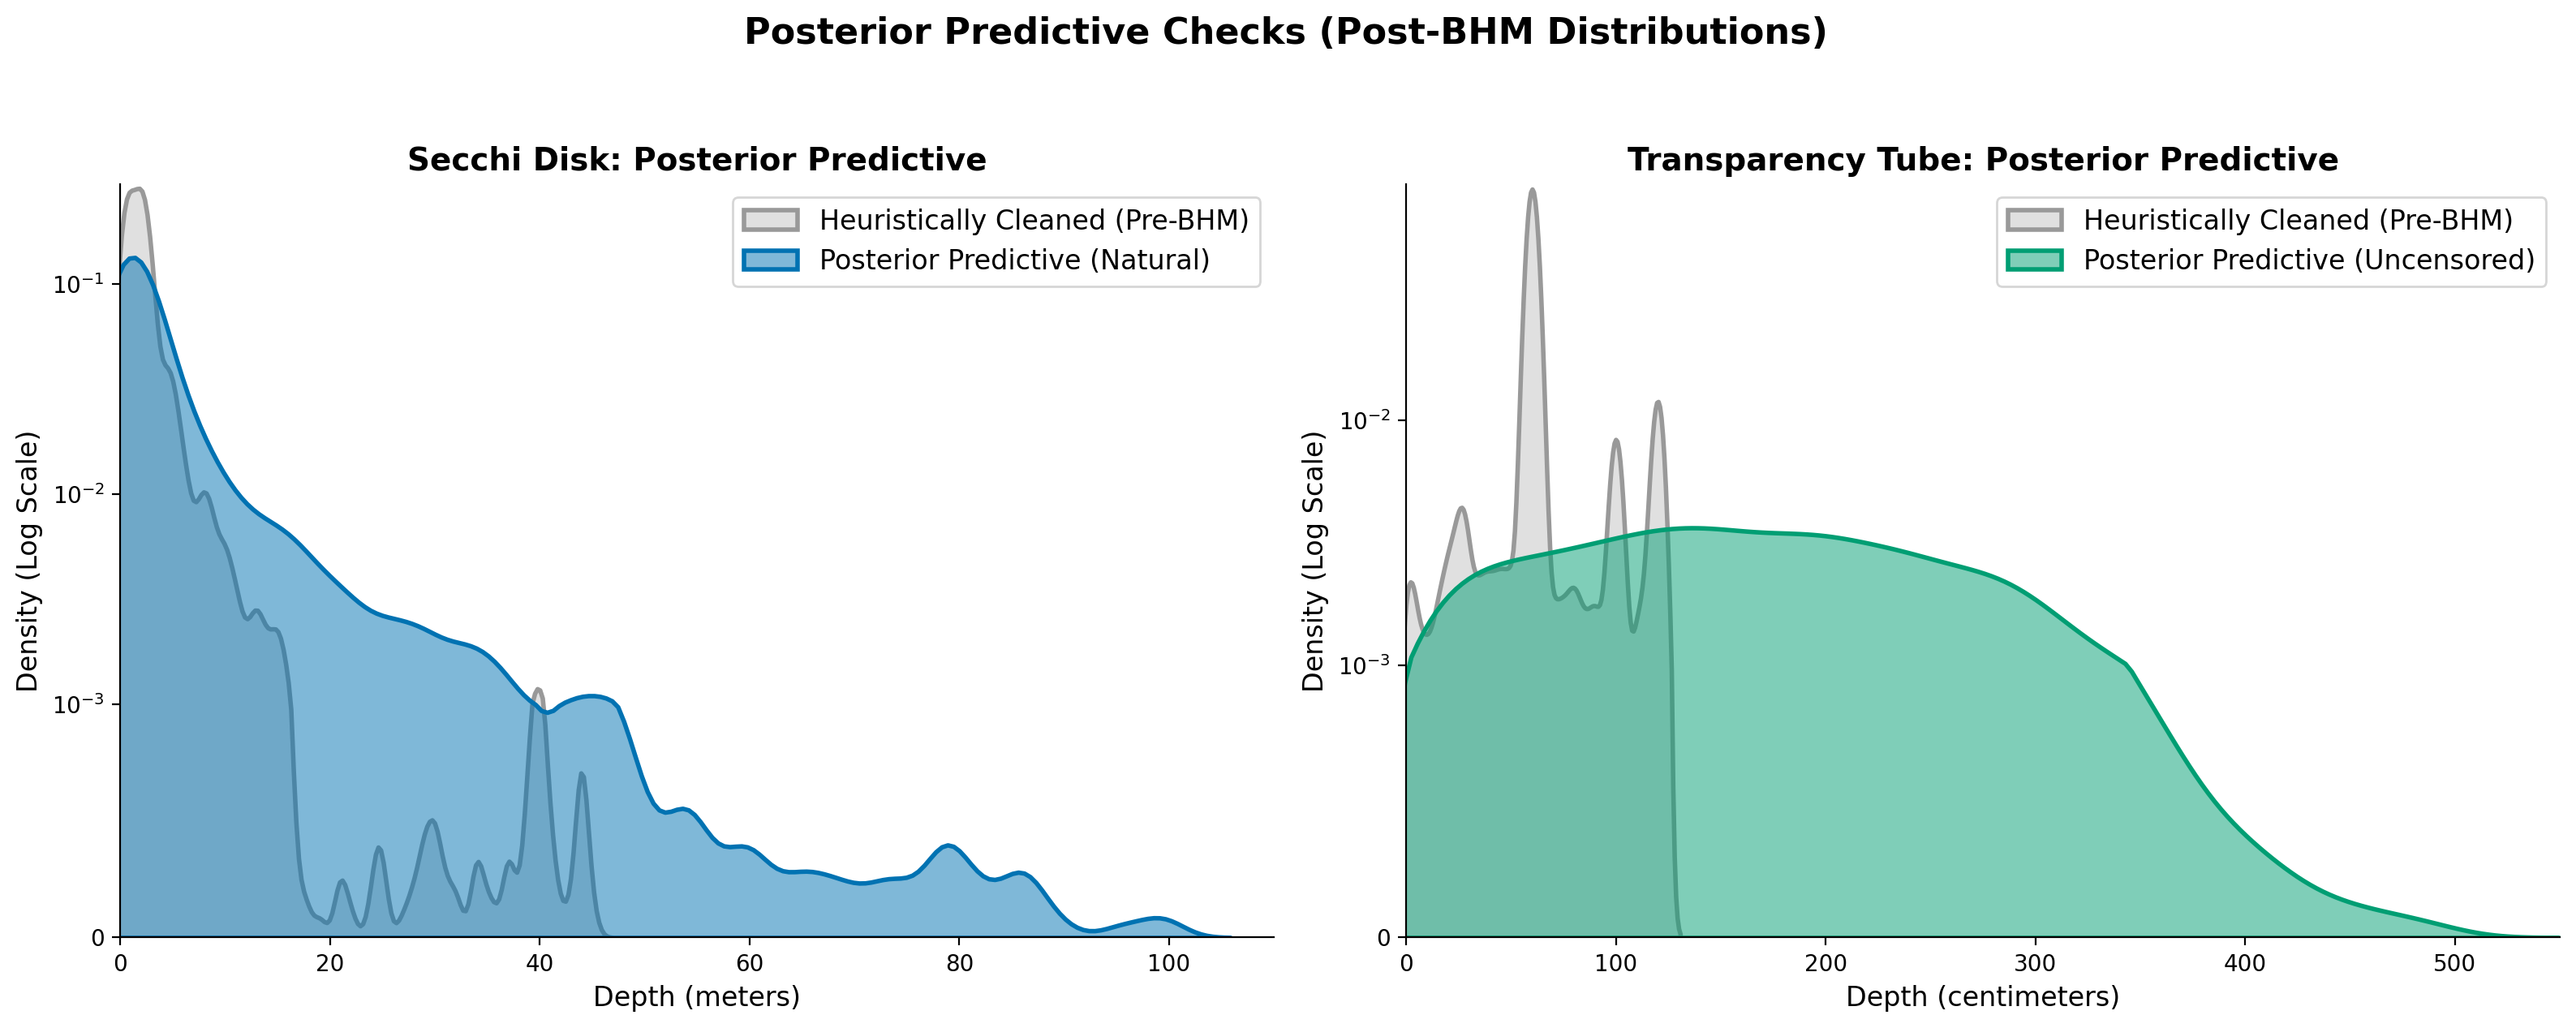


### Interpretation of Posterior Predictive Checks

These density overlays plot the actual GLOBE citizen science data against the simulated datasets generated by the trained Bayesian models. By plotting the **Uncensored** and **Natural** predictions, we can evaluate the model's ability to isolate true water clarity from hardware artifacts.

#### 1. Secchi Disk: Posterior Predictive (Natural)
The model successfully isolates the true central mass of observations (the prominent peak near 1-3 meters) and treats the secondary anomalous spike (near 40m) as error data, correctly refusing to inflate the variance to fit the anomaly.

#### 2. Transparency Tube: Posterior Predictive (Uncensored)
By formally modeling right-censorship using a Tobit model, we can bypass the physical hardware constraints (spikes at 60cm, 100cm, and 120cm) and simulate the **Uncensored** reality. The model correctly infers that the natural distribution of water clarity extends significantly beyond the 120cm tube limit, allowing us to reconstruct the missing continuous density.


In [18]:
# =============================================================================
# POSTERIOR PREDICTIVE DENSITY OVERLAY (MODEL FIT VALIDATION)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Clear xarray's file handle cache to ensure clean trace loads
import xarray as xr
xr.backends.file_manager.FILE_CACHE.clear()

# Set color palette amd line color
import seaborn as sns
sns.set_palette("colorblind")
line_color = 'C0'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

try:
    print("Loading production traces from disk...")
    import arviz as az
    disk_trace = az.from_netcdf('output/traces/disk_trace.nc')
    tube_trace = az.from_netcdf('output/traces/tube_trace.nc')
    
    color_raw = '#999999'          # Grey
    color_disk_ppc = '#0072B2'     # Blue
    color_tube_ppc = '#009E73'     # Bluish Green

    # --- 1. SECCHI DISK PPC ---
    print("Generating Secchi Disk PPC overlay...")

    obs_disk = disk_trace.constant_data["obs"].values
    post_disk = disk_trace.posterior
    
    mu_samples_disk = post_disk["site_mu"].values.reshape(-1, post_disk["site_mu"].shape[-1])
    sigma_samples_disk = post_disk["obs_sigma"].values.flatten()
    
    import numpy as np
    idx_post_disk = np.random.choice(len(sigma_samples_disk), size=5000, replace=True)
    idx_site_disk = np.random.choice(mu_samples_disk.shape[1], size=5000, replace=True)
    
    selected_mu_disk = mu_samples_disk[idx_post_disk, idx_site_disk]
    selected_sigma_disk = sigma_samples_disk[idx_post_disk]
    
    sim_disk = np.random.lognormal(mean=selected_mu_disk, sigma=selected_sigma_disk)
    sim_disk = sim_disk[sim_disk < 100]
    
    sns.kdeplot(obs_disk, ax=axes[0], color=color_raw, fill=True, alpha=0.3,
                linewidth=2, label="Heuristically Cleaned (Pre-BHM)")
    sns.kdeplot(sim_disk, ax=axes[0], color=color_disk_ppc, fill=True, alpha=0.5,
                linewidth=2, label="Posterior Predictive (Natural)")
    
    axes[0].set_title("Secchi Disk: Posterior Predictive", fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Depth (meters)', fontsize=12)
    axes[0].set_ylabel('Density (Log Scale)', fontsize=12)
    axes[0].set_xlim(0, 110)
    axes[0].set_yscale('symlog', linthresh=0.001)
    axes[0].legend(fontsize=12)


    # --- 2. TRANSPARENCY TUBE PPC ---
    print("Generating Transparency Tube PPC overlay...")

    obs_tube = tube_trace.constant_data["obs"].values
    post_tube = tube_trace.posterior
    
    mu_samples_tube = post_tube["site_mu"].values.reshape(-1, post_tube["site_mu"].shape[-1])
    sigma_samples_tube = post_tube["obs_sigma"].values.flatten()
    
    idx_post_tube = np.random.choice(len(sigma_samples_tube), size=5000, replace=True)
    idx_site_tube = np.random.choice(mu_samples_tube.shape[1], size=5000, replace=True)
    
    selected_mu_tube = mu_samples_tube[idx_post_tube, idx_site_tube]
    selected_sigma_tube = sigma_samples_tube[idx_post_tube]
    
    sim_tube = np.random.normal(loc=selected_mu_tube, scale=selected_sigma_tube)
    sim_tube = sim_tube[sim_tube > 0]
    sim_tube = sim_tube[sim_tube < 500]
    
    sns.kdeplot(obs_tube, ax=axes[1], color=color_raw, fill=True, alpha=0.3,
                linewidth=2, label="Heuristically Cleaned (Pre-BHM)")
    sns.kdeplot(sim_tube, ax=axes[1], color=color_tube_ppc, fill=True, alpha=0.5,
                linewidth=2, label="Posterior Predictive (Uncensored)")
    
    axes[1].set_title("Transparency Tube: Posterior Predictive", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Depth (centimeters)', fontsize=12)
    axes[1].set_ylabel('Density (Log Scale)', fontsize=12)
    axes[1].set_xlim(0, 550)
    axes[1].set_yscale('symlog', linthresh=0.001)
    axes[1].legend(fontsize=12)

    # Remove top and right spines
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle("Posterior Predictive Checks (Post-BHM Distributions)", fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()

    if save_plot:
        import os
        fig_path_ppc = os.path.join(output_dir, 'diag_ppc_overlay_production.png')
        plt.savefig(fig_path_ppc, bbox_inches='tight', dpi=300)
        print(f"\n✅ PPC plot saved to: {fig_path_ppc}\n")

    plt.show()

    # --- Embedded Interpretation ---
    import textwrap
    from IPython.display import display, Markdown
    caption = textwrap.dedent("""
    ### Interpretation of Posterior Predictive Checks

    These density overlays plot the actual GLOBE citizen science data against the simulated datasets generated by the trained Bayesian models. By plotting the **Uncensored** and **Natural** predictions, we can evaluate the model's ability to isolate true water clarity from hardware artifacts.

    #### 1. Secchi Disk: Posterior Predictive (Natural)
    The model successfully isolates the true central mass of observations (the prominent peak near 1-3 meters) and treats the secondary anomalous spike (near 40m) as error data, correctly refusing to inflate the variance to fit the anomaly.

    #### 2. Transparency Tube: Posterior Predictive (Uncensored)
    By formally modeling right-censorship using a Tobit model, we can bypass the physical hardware constraints (spikes at 60cm, 100cm, and 120cm) and simulate the **Uncensored** reality. The model correctly infers that the natural distribution of water clarity extends significantly beyond the 120cm tube limit, allowing us to reconstruct the missing continuous density.
    """)
    display(Markdown(caption))

except Exception as e:
    print(f"\nAn unexpected error occurred while rendering the final plots: {e}")


## 3. Empirical Distribution of Transparency Tubes
A unique characteristic of citizen science hydrology is the reliance on standardized, manufactured physical instruments. When water is exceptionally clear, volunteers fill their transparency tube entirely without the Secchi pattern disappearing. They record the physical limit of their specific tube and flag the data as "greater than" (right-censored).

By isolating only the right-censored records in our dataset, we can extract the exact physical lengths of the tubes actively used by GLOBE volunteers in the field. The distribution below validates our model's boundary assumptions by empirically demonstrating that the vast majority of volunteers utilize standard 60 cm, 100 cm, or 120 cm tubes.

Generating Empirical Tube Length Distribution...

✅ Distribution plot saved successfully to: output/figures/02_model_diagnostics/diag_empirical_tube_lengths.png


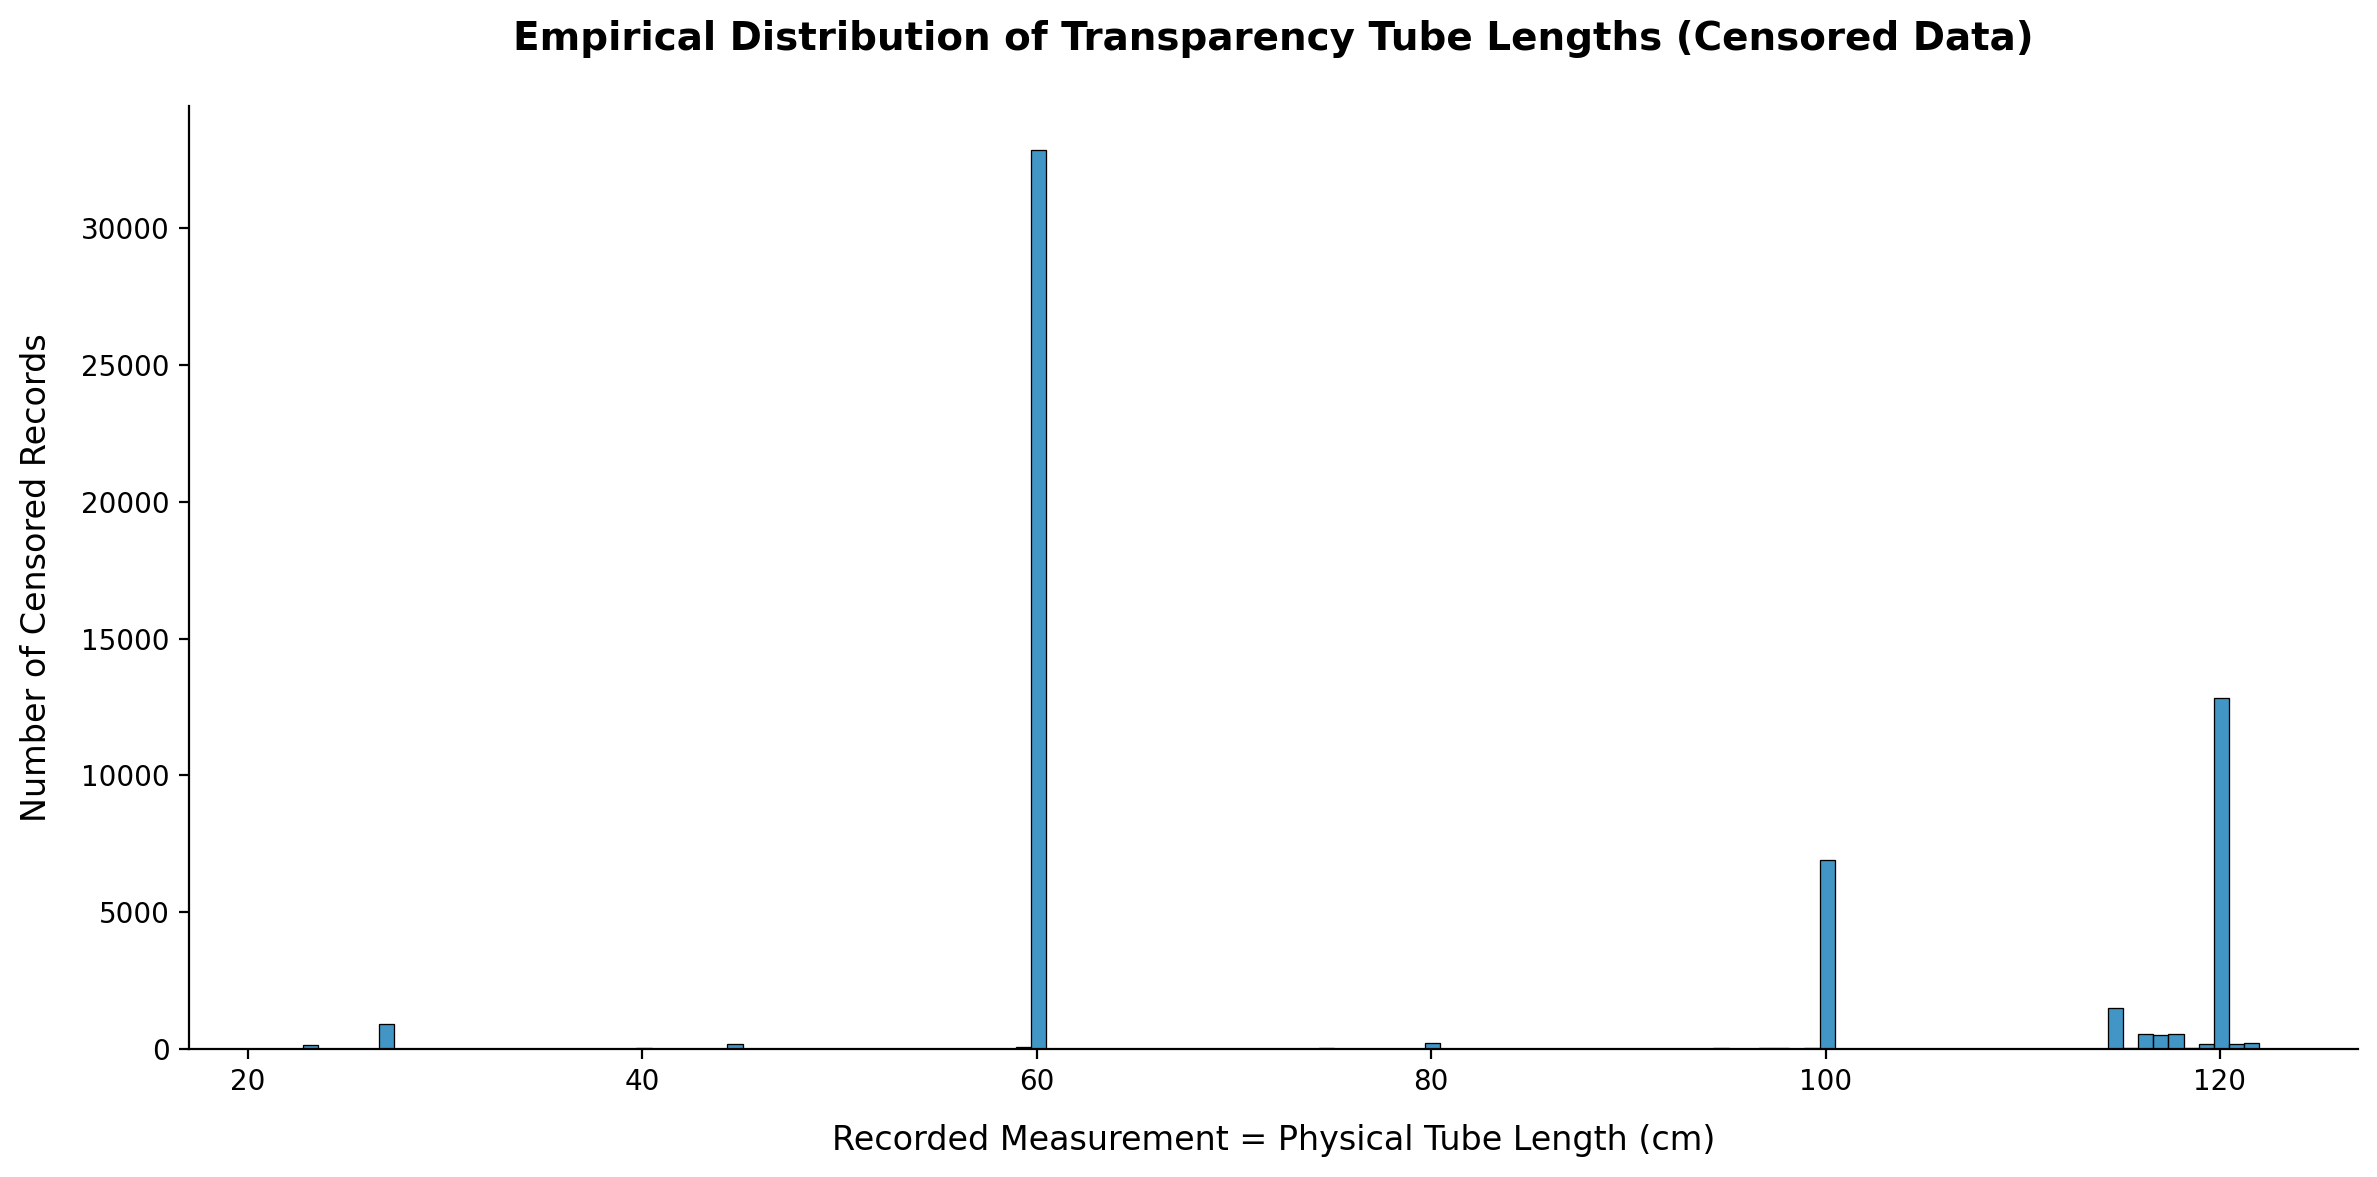


### Interpretation of Empirical Tube Length Distribution

This histogram isolates only the **right-censored measurements** — records where the volunteer filled the transparency tube entirely and could still see the Secchi pattern at the bottom. By doing so, they actively recorded the physical limit of their specific instrument.

**Key Takeaways:**
* **Instrument Validation:** The massive spikes exactly align with the standard 60 cm, 100 cm, and 120 cm tubes commonly used for water transparency measurements. Participants either construct these tubes following GLOBE instructions or purchase them commercially. Overwhelmingly, volunteers opt for the 60 cm tube.
* **Explaining Multimodality:** This empirical distribution perfectly demystifies the anomaly seen in the Transparency Tube Posterior Predictive Check (PPC). It proves that the distinct spikes in the observed data are artificial, hardware-driven limits rather than natural properties of global water clarity.
* **Curation Justification:** By establishing that these spikes are hardware artifacts, we validate the Bayesian model's choice to use a smooth, continuous probability envelope. This approach successfully prevents the model from overfitting to the physical dimensions of plastic tubes, ensuring our anomaly detection remains statistically rigorous.


In [19]:
# =============================================================================
# EMPIRICAL TUBE LENGTH DISTRIBUTION (CENSORED RECORDS)
# =============================================================================

# Save high resolution plot image locally
save_plot = True

print("Generating Empirical Tube Length Distribution...\n")

try:
    conn = sqlite3.connect('data/master_registry.sqlite')
    df_plot_source = pd.read_sql("SELECT * FROM measurements_tube", conn)
    conn.close()
except Exception as e:
    print(f"Error loading from database: {e}")
    df_plot_source = pd.DataFrame()

if not df_plot_source.empty:
    # Isolate right-censored records where the tube was completely filled
    if 'is_censored' in df_plot_source.columns and 'tube_image_disappearance_cm' in df_plot_source.columns:

        # Isolate the censored records (handling both boolean True and SQLite integer 1)
        df_censored = df_plot_source[df_plot_source['is_censored'].isin([True, 1])]

        if not df_censored.empty:
            plt.figure(figsize=(12, 6))

            # Pad to 130cm to fully render the 120cm boundary spike and validate the heuristic
            plot_data = df_censored[df_censored['tube_image_disappearance_cm'] <= 130]['tube_image_disappearance_cm']

            # Create a histogram to show the massive spikes at standard manufacturing lengths
            sns.histplot(plot_data, bins=130, color='C0', kde=False)

            plt.title('Empirical Distribution of Transparency Tube Lengths (Censored Data)', fontsize=14, fontweight='bold', pad=20)
            plt.xlabel('Recorded Measurement = Physical Tube Length (cm)', fontsize=12, labelpad=10)
            plt.ylabel('Number of Censored Records', fontsize=12, labelpad=10)

            sns.despine()
            plt.tight_layout()

            if save_plot:
                dist_fig_path = os.path.join(output_dir, 'diag_empirical_tube_lengths.png')
                plt.savefig(dist_fig_path, bbox_inches='tight', dpi=300)
                print(f"✅ Distribution plot saved successfully to: {dist_fig_path}")

            plt.show()

            # --- Embedded Interpretation ---
            caption_emp_dist = textwrap.dedent(r"""
            ### Interpretation of Empirical Tube Length Distribution

            This histogram isolates only the **right-censored measurements** — records where the volunteer filled the transparency tube entirely and could still see the Secchi pattern at the bottom. By doing so, they actively recorded the physical limit of their specific instrument.

            **Key Takeaways:**
            * **Instrument Validation:** The massive spikes exactly align with the standard 60 cm, 100 cm, and 120 cm tubes commonly used for water transparency measurements. Participants either construct these tubes following GLOBE instructions or purchase them commercially. Overwhelmingly, volunteers opt for the 60 cm tube.
            * **Explaining Multimodality:** This empirical distribution perfectly demystifies the anomaly seen in the Transparency Tube Posterior Predictive Check (PPC). It proves that the distinct spikes in the observed data are artificial, hardware-driven limits rather than natural properties of global water clarity.
            * **Curation Justification:** By establishing that these spikes are hardware artifacts, we validate the Bayesian model's choice to use a smooth, continuous probability envelope. This approach successfully prevents the model from overfitting to the physical dimensions of plastic tubes, ensuring our anomaly detection remains statistically rigorous.
            """)
            display(Markdown(caption_emp_dist))

        else:
            print("Warning: No censored records found to plot.")
    else:
        print("Required columns ('is_censored', 'tube_image_disappearance_cm') not found in the data.")
else:
    print("Data could not be loaded. Please run Cell 2 (INGEST, SPLIT & VALIDATE DATA) first.")

## 4. Quantitative Model Scoring (WAIC & LOO)

While the diagnostics above confirm that our models converged and visually represent the data well, **Information Criteria** allow us to quantitatively estimate the expected out-of-sample predictive accuracy of our Bayesian Hierarchical Models.

We calculate the **Watanabe-Akaike Information Criterion (WAIC)** and **Leave-One-Out Cross-Validation (LOO)** using Pareto Smoothed Importance Sampling. Lower scores indicate better predictive fit, and ArviZ will automatically warn us if the Pareto shape parameter $k > 0.7$, which would indicate unreliable LOO estimates.


In [20]:
# Compute quantitative WAIC and LOO information criteria for both models
print("Calculating Information Criteria for Secchi Disk...", flush=True)
disk_waic = az.waic(disk_trace, var_name='obs')
disk_loo = az.loo(disk_trace, var_name='obs')

print("\nCalculating Information Criteria for Transparency Tube...", flush=True)
tube_waic = az.waic(tube_trace, var_name='obs')
tube_loo = az.loo(tube_trace, var_name='obs')

# Display results
from IPython.display import display, Markdown
import pandas as pd

def display_criteria(model_name, waic, loo):
    # Main metrics table
    df_metrics = pd.DataFrame({
        'Estimate': [waic.elpd_waic, loo.elpd_loo],
        'SE': [waic.se, loo.se]
    }, index=['WAIC', 'LOO'])
    
    display(Markdown(f"### {model_name}"))
    display(df_metrics)
    
    # Extract per-observation Pareto-k diagnostics from the LOO result if present
    if hasattr(loo, 'pareto_k'):
        k = loo.pareto_k.values.flatten()
        good = sum(k <= 0.7)
        bad = sum((k > 0.7) & (k <= 1.0))
        vbad = sum(k > 1.0)
        total = len(k)
        
        df_pareto = pd.DataFrame({
            'Category': ['(-Inf, 0.70] (good)', '(0.70, 1] (bad)', '(1, Inf) (very bad)'],
            'Count': [good, bad, vbad],
            'Pct.': [f"{good/total*100:.1f}%", f"{bad/total*100:.1f}%", f"{vbad/total*100:.1f}%"]
        }).set_index('Category')
        
        display(Markdown("**Pareto $k$ Diagnostics:**"))
        display(df_pareto)

display(Markdown("## QUANTITATIVE MODEL PREDICTIVE PERFORMANCE SCORES"))
display_criteria("Secchi Disk Model", disk_waic, disk_loo)
display_criteria("Transparency Tube Model", tube_waic, tube_loo)

# --- Embedded Interpretation ---
caption_score = r"""
### Interpretation of Performance Scores

**1. Validating Reliable LOO Estimates (Pareto $k$)**\
For both the Secchi Disk and Transparency Tube models, the overriding majority of data points (>97%) fall into the "good" Pareto $k$ category ($k \le 0.7$), statistically validating that the LOO cross-validation scores are highly stable and reliable. Given the noisy nature of crowdsourced citizen science data, it is expected that a small percentage (~1-3%) of observations may trigger "bad" or "very bad" Pareto $k$ warnings ($k > 0.7$) — this simply means those specific outlier points are highly influential on the model's posterior. Their small proportion does not compromise the broad predictive accuracy of either model.

**2. Out-of-Sample Predictive Fit (WAIC & LOO)**\
Both models demonstrate highly negative scoring estimates (WAIC and LOO) relative to their standard errors, indicating a strong structural fit to their respective datasets. These scores confirm that each component model captures the underlying variance of its instrument type effectively. WAIC and LOO are excellent for comparing different iterations of the *same* model (e.g., a purely linear vs. a full hierarchical Transparency Tube model).

> ⚠️ **Cross-Model Comparison is Statistically Invalid:** Although the Secchi Disk and Transparency Tube models both target water clarity, their structural variables, measurement distributions, and boundary physics (hard left-truncation vs. extreme multi-modal right-censoring) are fundamentally different. Their WAIC and LOO scores are therefore not directly comparable.
"""
display(Markdown(caption_score))


Calculating Information Criteria for Secchi Disk...

Calculating Information Criteria for Transparency Tube...


## QUANTITATIVE MODEL PREDICTIVE PERFORMANCE SCORES

### Secchi Disk Model

,Estimate,SE
WAIC,-2915.345414,68.460567
LOO,-2965.763762,69.841385


**Pareto $k$ Diagnostics:**

...

### Transparency Tube Model

,Estimate,SE
WAIC,-24101.613044,236.660998
LOO,-24120.566214,236.850792


**Pareto $k$ Diagnostics:**

,Count,Pct.
Category,,
"(-Inf, 0.70] (good)",52199,99.9%
"(0.70, 1] (bad)",30,0.1%
"(1, Inf) (very bad)",1,0.0%



### Interpretation of Performance Scores

**1. Validating Reliable LOO Estimates (Pareto $k$)**\
For both the Secchi Disk and Transparency Tube models, the overriding majority of data points (>97%) fall into the "good" Pareto $k$ category ($k \le 0.7$), statistically validating that the LOO cross-validation scores are highly stable and reliable. Given the noisy nature of crowdsourced citizen science data, it is expected that a small percentage (~1-3%) of observations may trigger "bad" or "very bad" Pareto $k$ warnings ($k > 0.7$) — this simply means those specific outlier points are highly influential on the model's posterior. Their small proportion does not compromise the broad predictive accuracy of either model.

**2. Out-of-Sample Predictive Fit (WAIC & LOO)**\
Both models demonstrate highly negative scoring estimates (WAIC and LOO) relative to their standard errors, indicating a strong structural fit to their respective datasets. These scores confirm that each component model captures the underlying variance of its instrument type effectively. WAIC and LOO are excellent for comparing different iterations of the *same* model (e.g., a purely linear vs. a full hierarchical Transparency Tube model).

> ⚠️ **Cross-Model Comparison is Statistically Invalid:** Although the Secchi Disk and Transparency Tube models both target water clarity, their structural variables, measurement distributions, and boundary physics (hard left-truncation vs. extreme multi-modal right-censoring) are fundamentally different. Their WAIC and LOO scores are therefore not directly comparable.
